# 超参数搜索结果热力图分析

本notebook用于分析 `hyperparam_search_forget05_7b_mlp` 实验的结果，通过热力图可视化不同 alpha-beta 组合下的评估指标。

In [27]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ICML 风格设置 (Seaborn + Matplotlib)
sns.set_context("paper", font_scale=1.5) # 增大字体
sns.set_style("ticks") # 移除网格背景，保留刻度
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.grid": True,
    "grid.alpha": 0.3, # 淡化网格
    "grid.linestyle": "--",
    "figure.figsize": (10, 6),
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2,
    "lines.markersize": 8,
    "pdf.fonttype": 42, # 确保字体嵌入，方便论文排版
    "ps.fonttype": 42
})

## 1. 加载数据

In [28]:
# 数据目录
base_dir = Path('/cnz/data/project/my-open-unlearning/saves/unlearn/hyperparam_search_forget05_7b_mlp')

# 收集所有评估结果
results = []

for eval_dir in sorted(base_dir.glob('evals_a*_b*')):
    # 从文件夹名称提取 alpha 和 beta
    dir_name = eval_dir.name
    parts = dir_name.replace('evals_a', '').split('_b')
    alpha = float(parts[0])
    beta = float(parts[1])
    
    # 读取 TOFU_SUMMARY.json
    summary_file = eval_dir / 'TOFU_SUMMARY.json'
    if summary_file.exists():
        with open(summary_file, 'r') as f:
            metrics = json.load(f)
        
        # 添加 alpha 和 beta
        metrics['alpha'] = alpha
        metrics['beta'] = beta
        results.append(metrics)

# 转换为 DataFrame
df = pd.DataFrame(results)

# 按 alpha 和 beta 排序
df = df.sort_values(['alpha', 'beta']).reset_index(drop=True)

print(f"加载了 {len(df)} 组实验结果")
print(f"\nAlpha 范围: {df['alpha'].min()} - {df['alpha'].max()}")
print(f"Beta 范围: {df['beta'].min()} - {df['beta'].max()}")
print(f"\n评估指标: {[col for col in df.columns if col not in ['alpha', 'beta']]}")

加载了 16 组实验结果

Alpha 范围: 0.9 - 1.2
Beta 范围: 0.8 - 1.1

评估指标: ['exact_memorization', 'extraction_strength', 'extraction_strength_retain', 'forget_Q_A_Prob', 'forget_Q_A_ROUGE', 'forget_quality', 'forget_truth_ratio', 'model_utility', 'privleak', 'retain_Q_A_Prob', 'retain_Q_A_ROUGE']


In [29]:
# 查看前几行数据
df.head()

,exact_memorization,extraction_strength,extraction_strength_retain,forget_Q_A_Prob,forget_Q_A_ROUGE,forget_quality,forget_truth_ratio,model_utility,privleak,retain_Q_A_Prob,retain_Q_A_ROUGE,alpha,beta
0,0.752531,0.101839,0.912443,0.295845,0.382776,0.393527,0.633985,0.633363,-52.512718,0.971218,0.917115,0.9,0.8
1,0.746008,0.101353,0.897230,0.282923,0.382249,0.270474,0.634674,0.633998,-49.780330,0.969015,0.909240,0.9,0.9
2,0.745073,0.100970,0.893861,0.280728,0.383643,0.270474,0.634059,0.634849,-49.194543,0.968007,0.907565,0.9,1.0
3,0.748130,0.100804,0.892924,0.292468,0.377300,0.220541,0.633933,0.635329,-51.907661,0.966532,0.902676,0.9,1.1
4,0.737163,0.098897,0.904210,0.264660,0.379978,0.220541,0.634396,0.631315,-45.675967,0.970041,0.913306,1.0,0.8


## 2. 创建热力图函数

In [30]:
def create_heatmap(df, metric_name, figsize=(10, 8), cmap='RdYlGn', annot=True, fmt='.3f'):
    """
    创建单个指标的热力图
    
    参数:
    - df: DataFrame，包含 alpha, beta 和各评估指标
    - metric_name: 要可视化的指标名称
    - figsize: 图形大小
    - cmap: 颜色映射 ('RdYlGn', 'viridis', 'coolwarm' 等)
    - annot: 是否在单元格中显示数值
    - fmt: 数值格式
    """
    # 创建数据透视表
    pivot_data = df.pivot(index='alpha', columns='beta', values=metric_name)
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 绘制热力图
    sns.heatmap(pivot_data, annot=annot, fmt=fmt, cmap=cmap, 
                cbar_kws={'label': metric_name},
                linewidths=0.5, linecolor='gray')
    
    plt.title(f'{metric_name} vs Alpha and Beta', fontsize=14, pad=20)
    plt.xlabel('Beta', fontsize=12)
    plt.ylabel('Alpha', fontsize=12)
    
    # 调整布局
    plt.tight_layout()
    
    return plt.gcf()

## 3. 可视化关键指标

### 3.1 Forget Quality (遗忘质量) - 越高越好

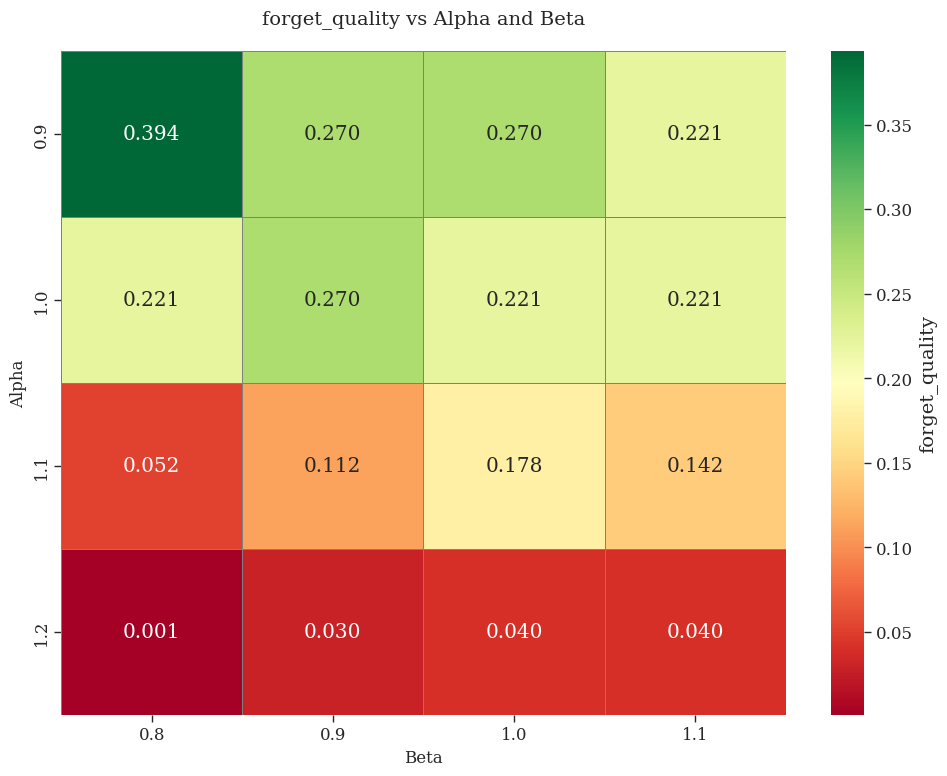

In [31]:
create_heatmap(df, 'forget_quality', cmap='RdYlGn')
plt.show()

### 3.2 Model Utility (模型效用) - 越高越好

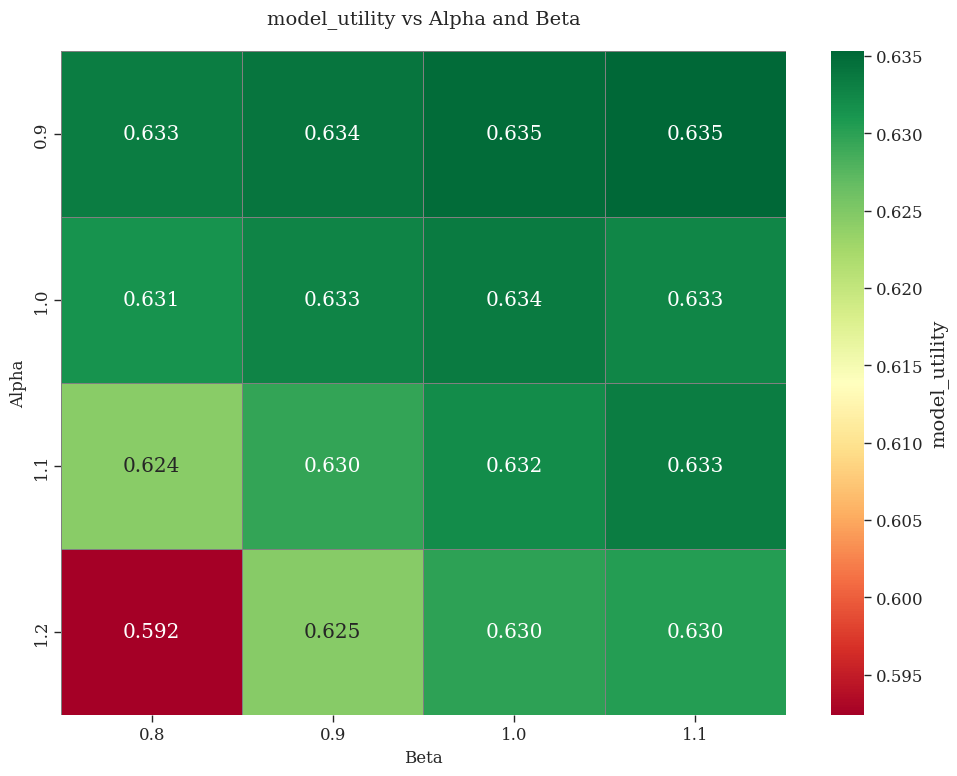

In [32]:
create_heatmap(df, 'model_utility', cmap='RdYlGn')
plt.show()

### 3.3 综合得分 (Forget Quality + Model Utility)

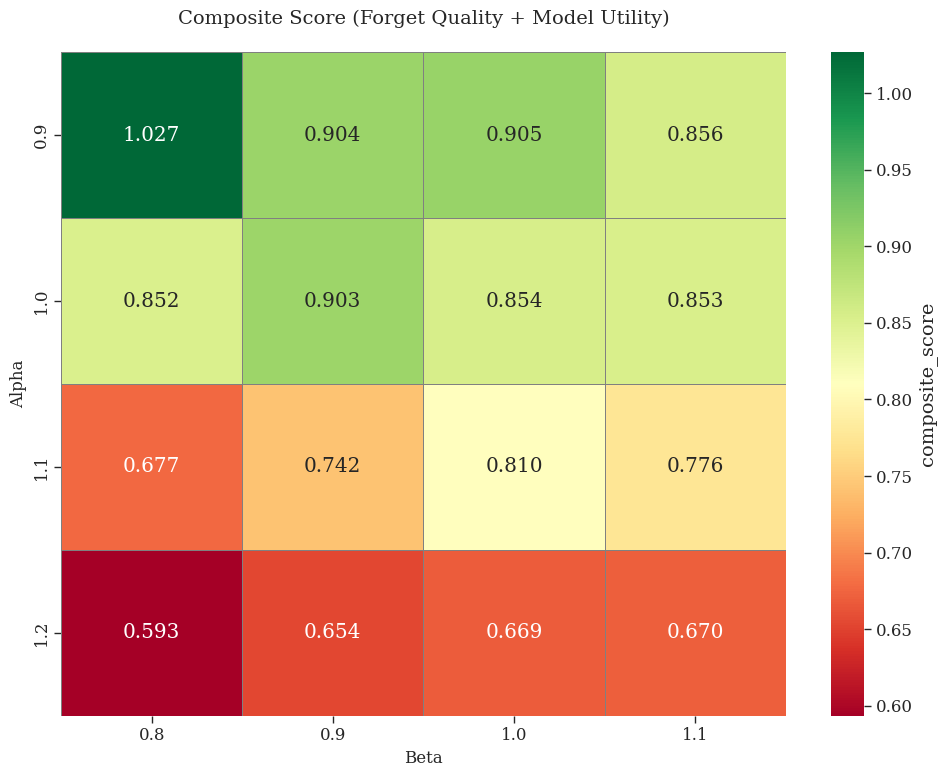

In [33]:
# 计算综合得分：高遗忘质量（好）+ 高模型效用（好）
df['composite_score'] = df['forget_quality'] + df['model_utility']

create_heatmap(df, 'composite_score', cmap='RdYlGn')
plt.title('Composite Score (Forget Quality + Model Utility)', fontsize=14, pad=20)
plt.show()

### 3.4 Extraction Strength (ES) - 越低越好

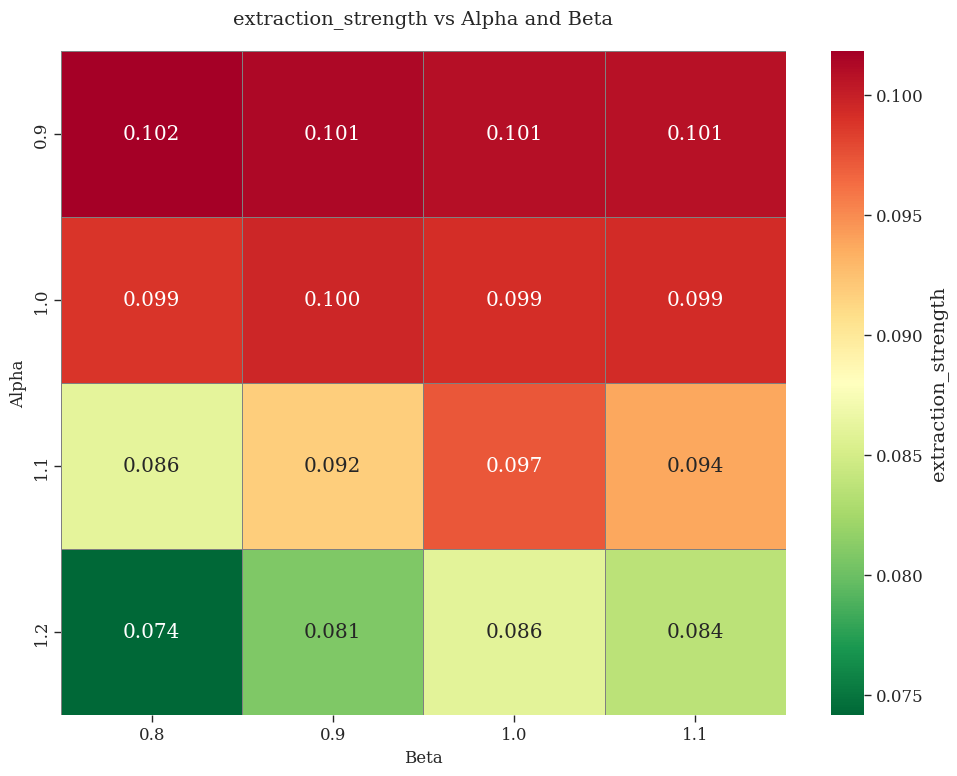

In [34]:
create_heatmap(df, 'extraction_strength', cmap='RdYlGn_r')
plt.show()

### 3.5 Extraction Strength Retain (ES RE) - 越高越好

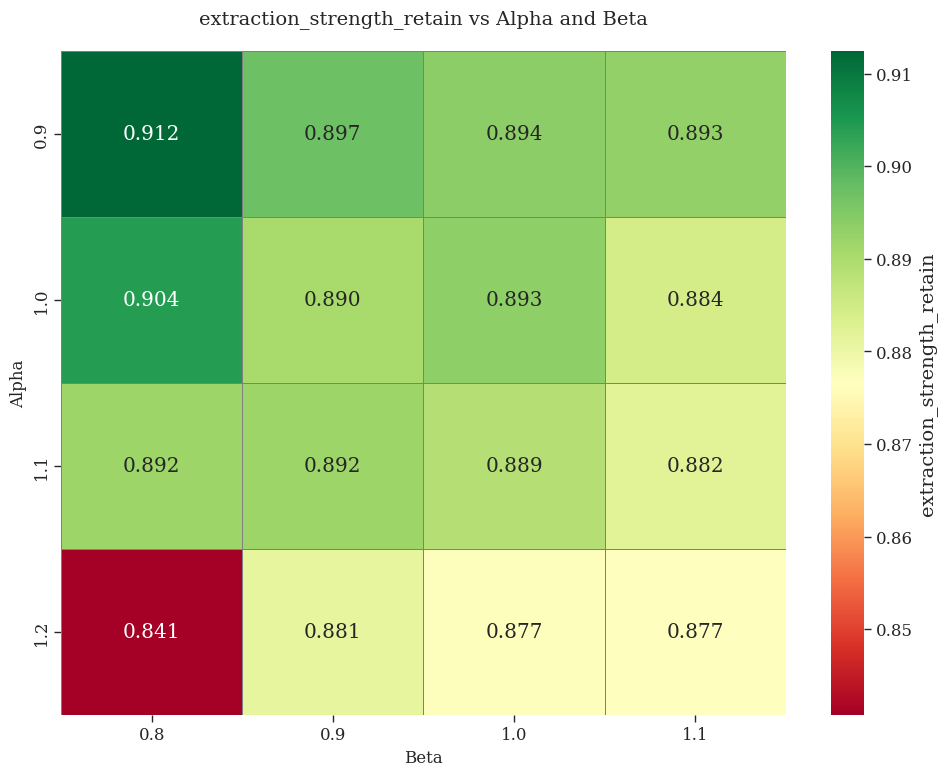

In [35]:
create_heatmap(df, 'extraction_strength_retain', cmap='RdYlGn')
plt.show()

### 3.6 基于 ES 和 ES RE 的综合评分

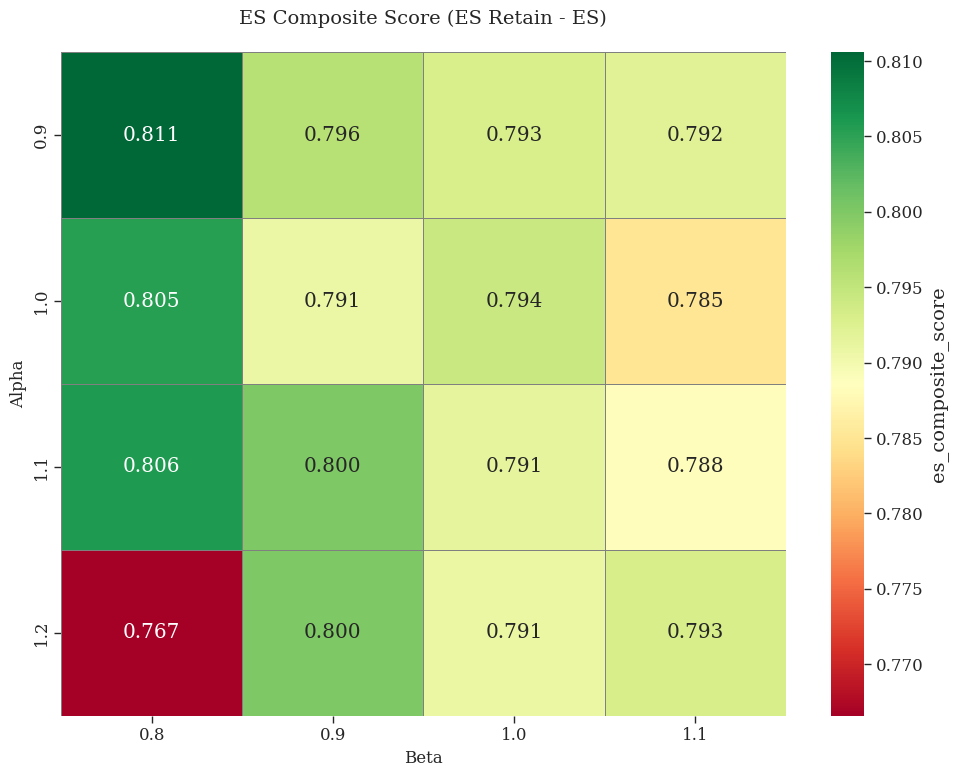

In [36]:
# 计算基于 ES 的综合得分：高 ES RE（好）- 低 ES（好）
df['es_composite_score'] = df['extraction_strength_retain'] - df['extraction_strength']

create_heatmap(df, 'es_composite_score', cmap='RdYlGn')
plt.title('ES Composite Score (ES Retain - ES)', fontsize=14, pad=20)
plt.show()

## 4. 所有指标的热力图

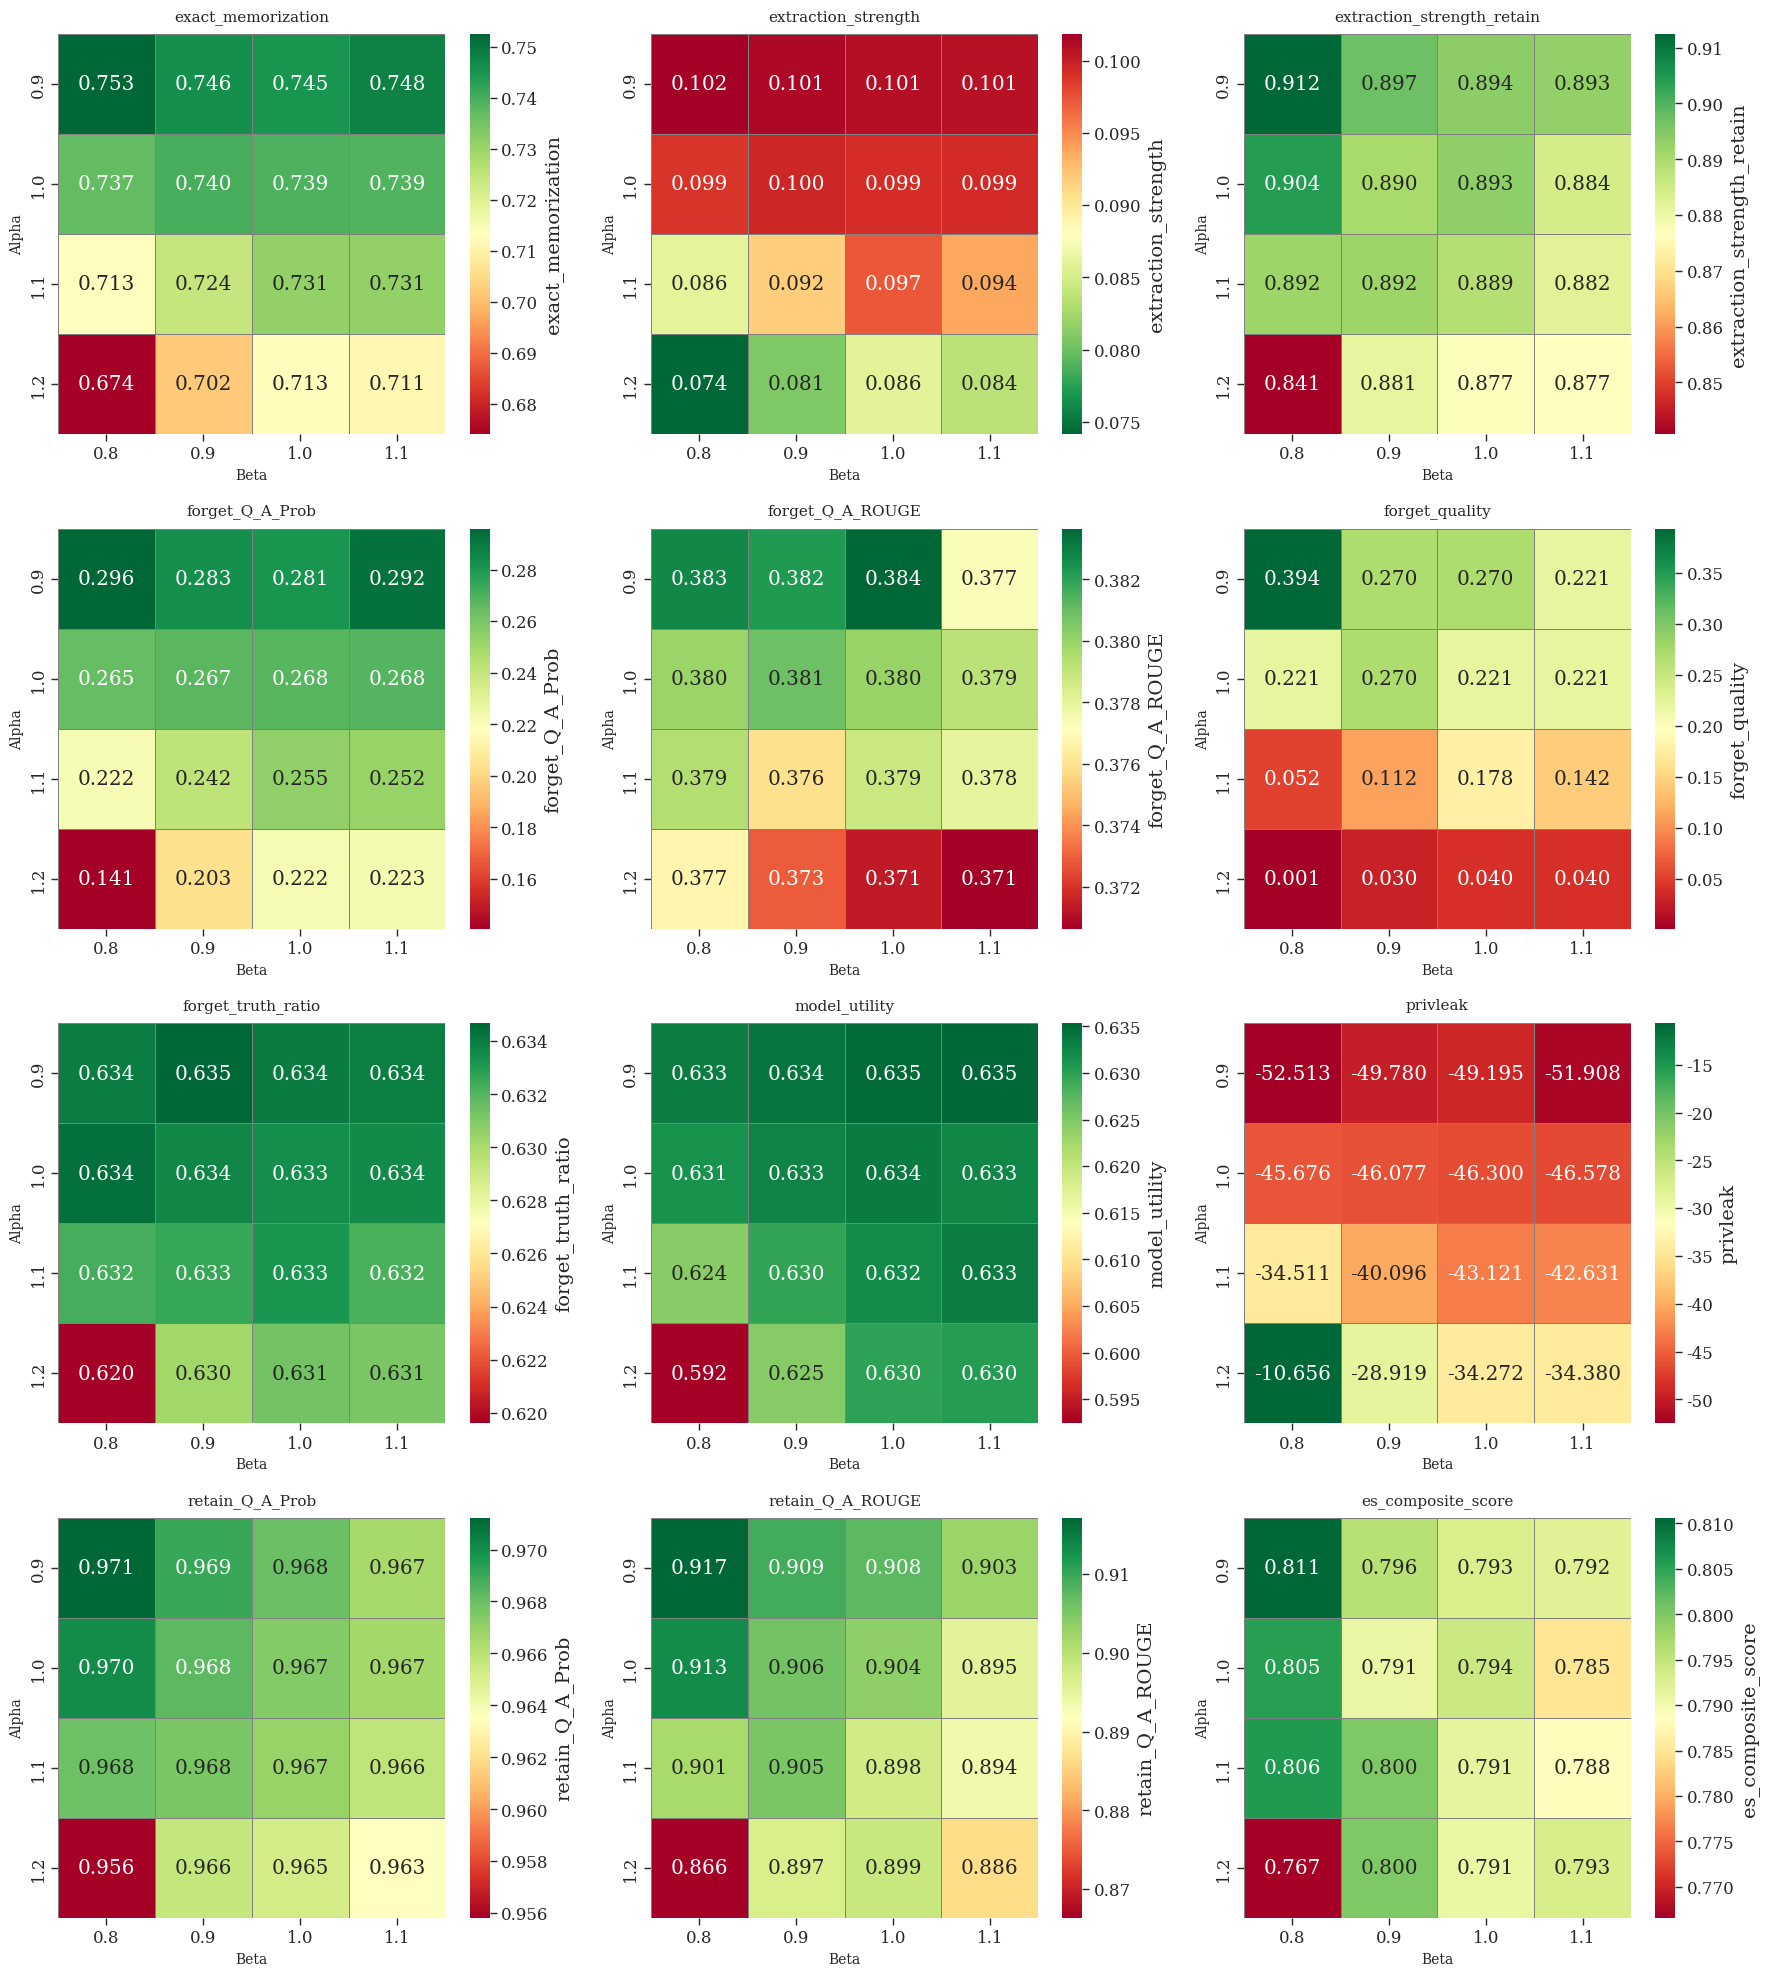

In [37]:
# 获取所有评估指标
metrics = [col for col in df.columns if col not in ['alpha', 'beta', 'composite_score']]

# 为每个指标创建热力图
n_metrics = len(metrics)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_metrics > 1 else [axes]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 创建数据透视表
    pivot_data = df.pivot(index='alpha', columns='beta', values=metric)
    
    # 选择合适的颜色映射
    # extraction_strength 越低越好，使用反向色图
    # 其他指标（包括 forget_quality）都是越高越好
    if metric == 'extraction_strength':
        cmap = 'RdYlGn_r'
    else:
        cmap = 'RdYlGn'
    
    # 绘制热力图
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': metric},
                linewidths=0.5, linecolor='gray')
    
    ax.set_title(metric, fontsize=11, pad=10)
    ax.set_xlabel('Beta', fontsize=10)
    ax.set_ylabel('Alpha', fontsize=10)

# 隐藏多余的子图
for idx in range(n_metrics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. 找出最优参数组合

In [38]:
# 基于不同标准找出最优参数
print("="*60)
print("最优参数组合分析")
print("="*60)

# 1. 最高遗忘质量
best_forget = df.loc[df['forget_quality'].idxmax()]
print(f"\n1. 最高遗忘质量:")
print(f"   Alpha={best_forget['alpha']}, Beta={best_forget['beta']}")
print(f"   Forget Quality: {best_forget['forget_quality']:.4f}")
print(f"   Model Utility: {best_forget['model_utility']:.4f}")

# 2. 最高模型效用
best_utility = df.loc[df['model_utility'].idxmax()]
print(f"\n2. 最高模型效用:")
print(f"   Alpha={best_utility['alpha']}, Beta={best_utility['beta']}")
print(f"   Forget Quality: {best_utility['forget_quality']:.4f}")
print(f"   Model Utility: {best_utility['model_utility']:.4f}")

# 3. 最佳综合得分
best_composite = df.loc[df['composite_score'].idxmax()]
print(f"\n3. 最佳综合得分 (Forget Quality + Model Utility):")
print(f"   Alpha={best_composite['alpha']}, Beta={best_composite['beta']}")
print(f"   Forget Quality: {best_composite['forget_quality']:.4f}")
print(f"   Model Utility: {best_composite['model_utility']:.4f}")
print(f"   Composite Score: {best_composite['composite_score']:.4f}")

# 4. 平衡方案：模型效用 > 0.6 且遗忘质量最高
balanced = df[df['model_utility'] > 0.6]
if len(balanced) > 0:
    best_balanced = balanced.loc[balanced['forget_quality'].idxmax()]
    print(f"\n4. 平衡方案 (Model Utility > 0.6 且遗忘质量最高):")
    print(f"   Alpha={best_balanced['alpha']}, Beta={best_balanced['beta']}")
    print(f"   Forget Quality: {best_balanced['forget_quality']:.4f}")
    print(f"   Model Utility: {best_balanced['model_utility']:.4f}")

# 5. 最低 Extraction Strength (ES)
best_es = df.loc[df['extraction_strength'].idxmin()]
print(f"\n5. 最低 Extraction Strength (ES ↓):")
print(f"   Alpha={best_es['alpha']}, Beta={best_es['beta']}")
print(f"   ES: {best_es['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es['es_composite_score']:.4f}")

# 6. 最高 Extraction Strength Retain (ES RE)
best_es_retain = df.loc[df['extraction_strength_retain'].idxmax()]
print(f"\n6. 最高 Extraction Strength Retain (ES RE ↑):")
print(f"   Alpha={best_es_retain['alpha']}, Beta={best_es_retain['beta']}")
print(f"   ES: {best_es_retain['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es_retain['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es_retain['es_composite_score']:.4f}")

# 7. 最佳 ES 综合得分
best_es_composite = df.loc[df['es_composite_score'].idxmax()]
print(f"\n7. 最佳 ES 综合得分 (ES Retain - ES):")
print(f"   Alpha={best_es_composite['alpha']}, Beta={best_es_composite['beta']}")
print(f"   ES: {best_es_composite['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es_composite['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es_composite['es_composite_score']:.4f}")

# 8. 平衡方案：ES Retain > 0.8 且 ES 最低
es_balanced = df[df['extraction_strength_retain'] > 0.8]
if len(es_balanced) > 0:
    best_es_balanced = es_balanced.loc[es_balanced['extraction_strength'].idxmin()]
    print(f"\n8. ES 平衡方案 (ES Retain > 0.8 且 ES 最低):")
    print(f"   Alpha={best_es_balanced['alpha']}, Beta={best_es_balanced['beta']}")
    print(f"   ES: {best_es_balanced['extraction_strength']:.4f}")
    print(f"   ES Retain: {best_es_balanced['extraction_strength_retain']:.4f}")
    print(f"   ES Composite: {best_es_balanced['es_composite_score']:.4f}")

print("\n" + "="*60)

最优参数组合分析

1. 最高遗忘质量:
   Alpha=0.9, Beta=0.8
   Forget Quality: 0.3935
   Model Utility: 0.6334

2. 最高模型效用:
   Alpha=0.9, Beta=1.1
   Forget Quality: 0.2205
   Model Utility: 0.6353

3. 最佳综合得分 (Forget Quality + Model Utility):
   Alpha=0.9, Beta=0.8
   Forget Quality: 0.3935
   Model Utility: 0.6334
   Composite Score: 1.0269

4. 平衡方案 (Model Utility > 0.6 且遗忘质量最高):
   Alpha=0.9, Beta=0.8
   Forget Quality: 0.3935
   Model Utility: 0.6334

5. 最低 Extraction Strength (ES ↓):
   Alpha=1.2, Beta=0.8
   ES: 0.0742
   ES Retain: 0.8407
   ES Composite: 0.7666

6. 最高 Extraction Strength Retain (ES RE ↑):
   Alpha=0.9, Beta=0.8
   ES: 0.1018
   ES Retain: 0.9124
   ES Composite: 0.8106

7. 最佳 ES 综合得分 (ES Retain - ES):
   Alpha=0.9, Beta=0.8
   ES: 0.1018
   ES Retain: 0.9124
   ES Composite: 0.8106

8. ES 平衡方案 (ES Retain > 0.8 且 ES 最低):
   Alpha=1.2, Beta=0.8
   ES: 0.0742
   ES Retain: 0.8407
   ES Composite: 0.7666



## 6. 参数敏感性分析

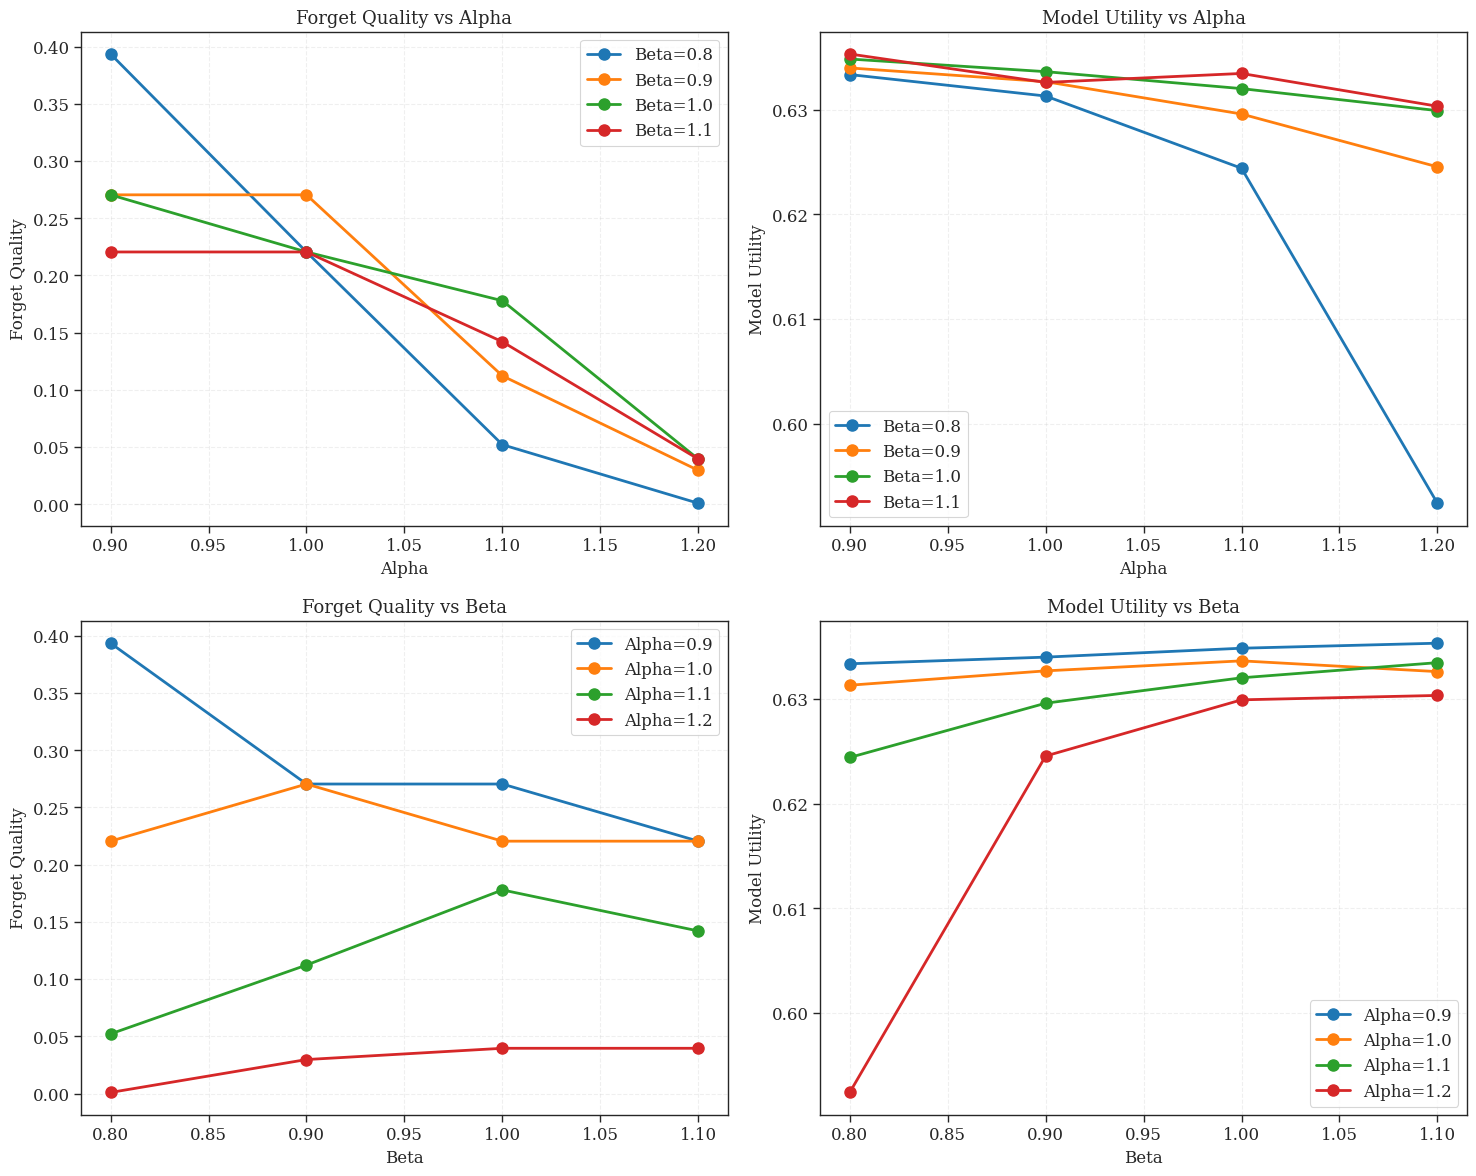

In [39]:
# 分析 alpha 和 beta 对关键指标的影响
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Forget Quality vs Alpha (不同 Beta 的曲线)
ax = axes[0, 0]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['forget_quality'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Forget Quality', fontsize=12)
ax.set_title('Forget Quality vs Alpha', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Model Utility vs Alpha
ax = axes[0, 1]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['model_utility'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Model Utility', fontsize=12)
ax.set_title('Model Utility vs Alpha', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Forget Quality vs Beta (不同 Alpha 的曲线)
ax = axes[1, 0]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['forget_quality'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Forget Quality', fontsize=12)
ax.set_title('Forget Quality vs Beta', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Model Utility vs Beta
ax = axes[1, 1]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['model_utility'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Model Utility', fontsize=12)
ax.set_title('Model Utility vs Beta', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 ES 和 ES Retain 参数敏感性分析

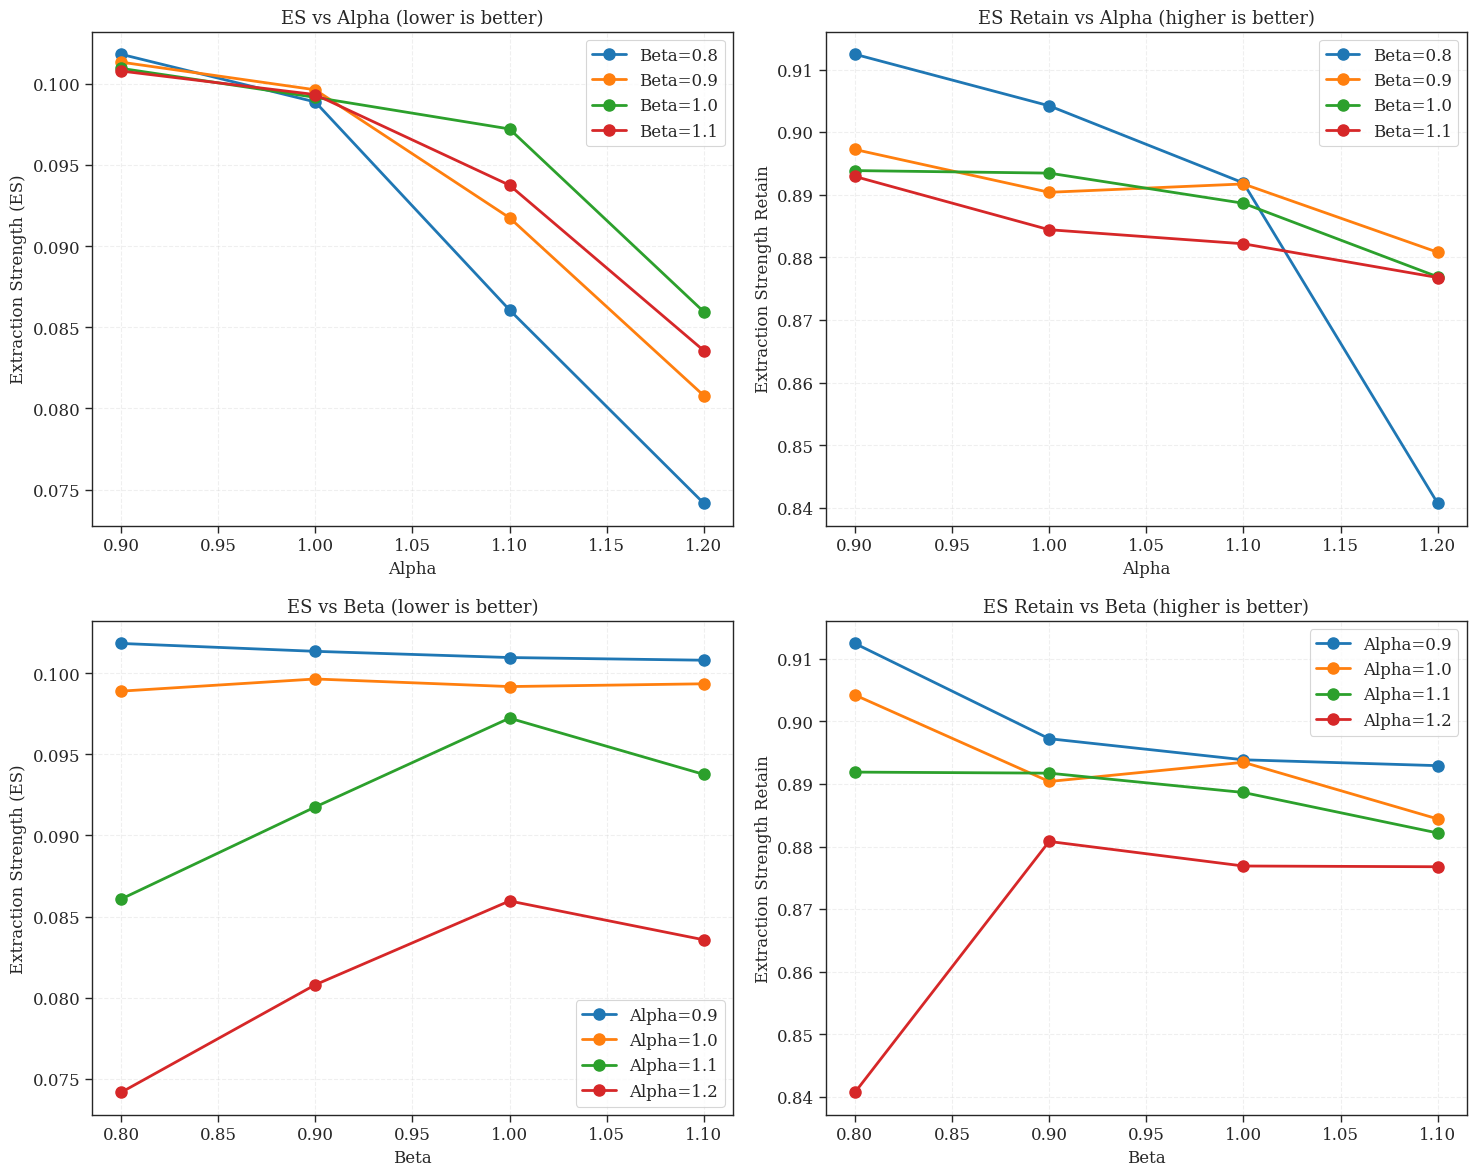

In [40]:
# 分析 alpha 和 beta 对 ES 指标的影响
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ES vs Alpha (不同 Beta 的曲线)
ax = axes[0, 0]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['extraction_strength'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Extraction Strength (ES)', fontsize=12)
ax.set_title('ES vs Alpha (lower is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. ES Retain vs Alpha
ax = axes[0, 1]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['extraction_strength_retain'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Extraction Strength Retain', fontsize=12)
ax.set_title('ES Retain vs Alpha (higher is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ES vs Beta (不同 Alpha 的曲线)
ax = axes[1, 0]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['extraction_strength'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Extraction Strength (ES)', fontsize=12)
ax.set_title('ES vs Beta (lower is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. ES Retain vs Beta
ax = axes[1, 1]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['extraction_strength_retain'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Extraction Strength Retain', fontsize=12)
ax.set_title('ES Retain vs Beta (higher is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 散点图：Forget Quality vs Model Utility

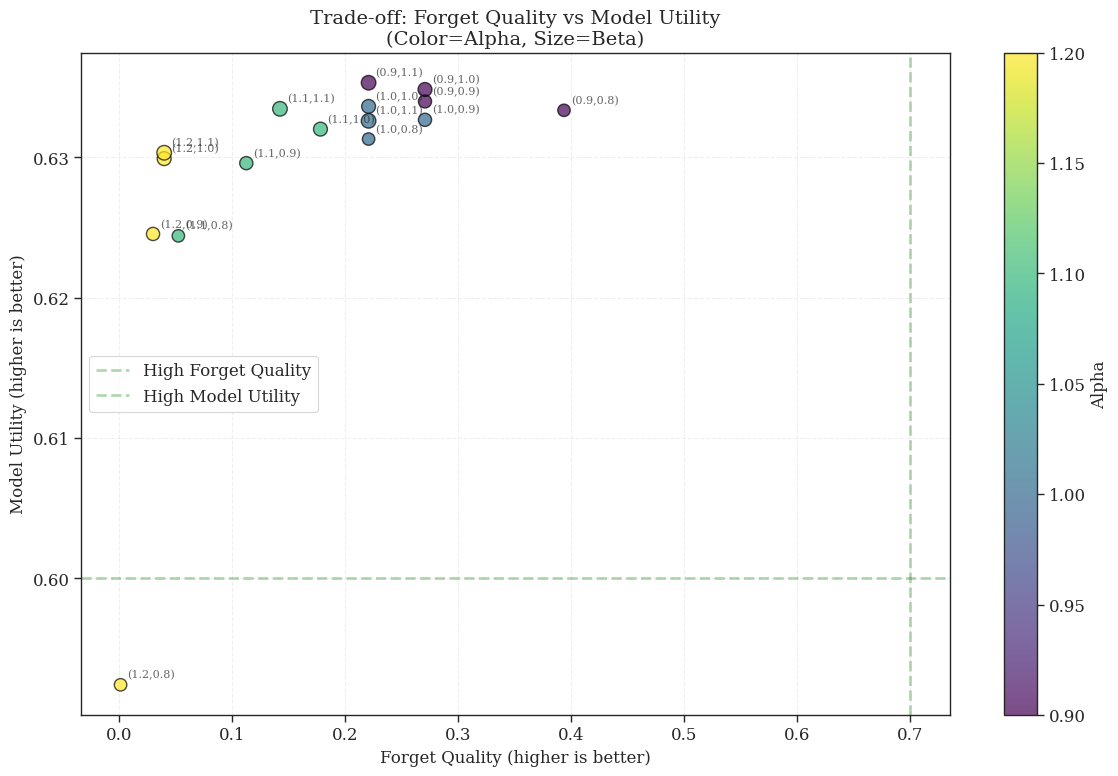

In [41]:
# 创建散点图，颜色表示 alpha，大小表示 beta
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['forget_quality'], df['model_utility'], 
                     c=df['alpha'], s=df['beta']*100, 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)

# 为每个点添加标签
for idx, row in df.iterrows():
    ax.annotate(f"({row['alpha']:.1f},{row['beta']:.1f})", 
                (row['forget_quality'], row['model_utility']),
                fontsize=8, alpha=0.7, xytext=(5, 5), 
                textcoords='offset points')

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Alpha', fontsize=12)

# 添加理想区域标注（高遗忘质量，高模型效用）
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.3, label='High Forget Quality')
ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.3, label='High Model Utility')

ax.set_xlabel('Forget Quality (higher is better)', fontsize=12)
ax.set_ylabel('Model Utility (higher is better)', fontsize=12)
ax.set_title('Trade-off: Forget Quality vs Model Utility\n(Color=Alpha, Size=Beta)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.1 散点图：ES vs ES Retain

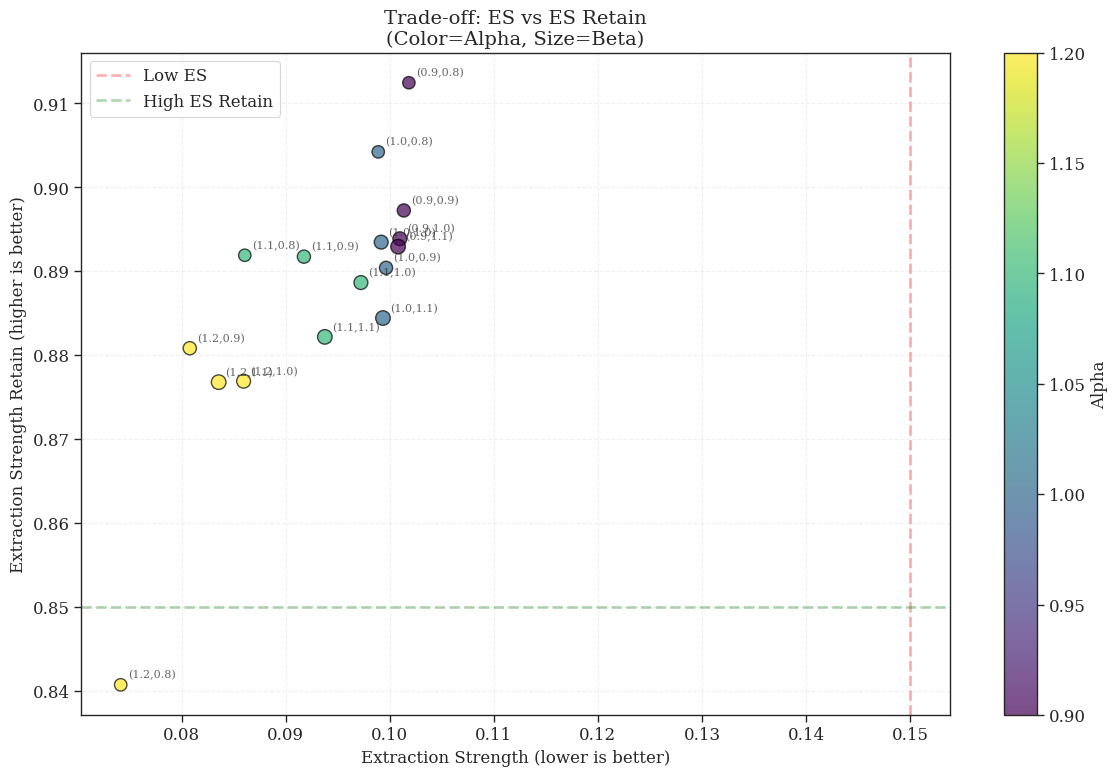

In [42]:
# 创建散点图，颜色表示 alpha，大小表示 beta
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['extraction_strength'], df['extraction_strength_retain'], 
                     c=df['alpha'], s=df['beta']*100, 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)

# 为每个点添加标签
for idx, row in df.iterrows():
    ax.annotate(f"({row['alpha']:.1f},{row['beta']:.1f})", 
                (row['extraction_strength'], row['extraction_strength_retain']),
                fontsize=8, alpha=0.7, xytext=(5, 5), 
                textcoords='offset points')

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Alpha', fontsize=12)

# 添加理想区域标注（低 ES，高 ES Retain）
ax.axvline(x=0.15, color='red', linestyle='--', alpha=0.3, label='Low ES')
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.3, label='High ES Retain')

ax.set_xlabel('Extraction Strength (lower is better)', fontsize=12)
ax.set_ylabel('Extraction Strength Retain (higher is better)', fontsize=12)
ax.set_title('Trade-off: ES vs ES Retain\n(Color=Alpha, Size=Beta)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 导出结果表格

In [43]:
# 按综合得分排序
df_sorted = df.sort_values('composite_score', ascending=False)

# 选择关键列
key_columns = ['alpha', 'beta', 'forget_quality', 'model_utility', 'composite_score', 
               'extraction_strength', 'extraction_strength_retain', 'es_composite_score',
               'retain_Q_A_Prob', 'forget_Q_A_Prob', 'exact_memorization']

# 显示前10个最佳配置（按综合得分）
print("Top 10 最佳参数配置 (按综合得分排序):\n")
print(df_sorted[key_columns].head(10).to_string(index=False))

# 显示前10个最佳配置（按 ES 综合得分）
print("\n" + "="*80)
print("\nTop 10 最佳参数配置 (按 ES 综合得分排序):\n")
df_sorted_es = df.sort_values('es_composite_score', ascending=False)
print(df_sorted_es[key_columns].head(10).to_string(index=False))

# 导出完整结果
output_file = base_dir / 'analysis_results.csv'
df_sorted.to_csv(output_file, index=False)
print(f"\n完整结果已保存到: {output_file}")

Top 10 最佳参数配置 (按综合得分排序):

 alpha  beta  forget_quality  model_utility  composite_score  extraction_strength  extraction_strength_retain  es_composite_score  retain_Q_A_Prob  forget_Q_A_Prob  exact_memorization
   0.9   0.8        0.393527       0.633363         1.026890             0.101839                    0.912443            0.810604         0.971218         0.295845            0.752531
   0.9   1.0        0.270474       0.634849         0.905324             0.100970                    0.893861            0.792892         0.968007         0.280728            0.745073
   0.9   0.9        0.270474       0.633998         0.904472             0.101353                    0.897230            0.795878         0.969015         0.282923            0.746008
   1.0   0.9        0.270474       0.632685         0.903160             0.099647                    0.890394            0.790747         0.968313         0.266871            0.739756
   0.9   1.1        0.220541       0.635329         0.

## 9. 统计摘要

In [44]:
# 显示所有指标的统计摘要
print("所有评估指标的统计摘要:\n")
print(df.describe().T.round(4))

所有评估指标的统计摘要:

                            count     mean      std      min      25%  \
exact_memorization           16.0   0.7279   0.0207   0.6740   0.7133   
extraction_strength          16.0   0.0935   0.0087   0.0742   0.0860   
extraction_strength_retain   16.0   0.8874   0.0156   0.8407   0.8818   
forget_Q_A_Prob              16.0   0.2487   0.0397   0.1407   0.2224   
forget_Q_A_ROUGE             16.0   0.3781   0.0039   0.3706   0.3765   
forget_quality               16.0   0.1676   0.1128   0.0010   0.0490   
forget_truth_ratio           16.0   0.6321   0.0036   0.6196   0.6319   
model_utility                16.0   0.6290   0.0103   0.5924   0.6298   
privleak                     16.0 -41.0383  10.6722 -52.5127 -47.2320   
retain_Q_A_Prob              16.0   0.9666   0.0034   0.9558   0.9658   
retain_Q_A_ROUGE             16.0   0.9001   0.0118   0.8663   0.8964   
alpha                        16.0   1.0500   0.1155   0.9000   0.9750   
beta                         16.0   0

## 10. 超参数稳定性分析 (Publication-Ready)

分析三个关键指标在不同 α (alpha) 和 β (beta) 超参数配置下的稳定性：
- **Extraction Strength (ES)** - 越低越好
- **ES Retain** - 越高越好
- **Model Utility (MU)** - 越高越好

本节提供适合学术论文发表的高质量可视化图表。

In [45]:
# 定义关键指标用于稳定性分析
key_metrics = ['extraction_strength', 'extraction_strength_retain', 'model_utility']
key_metric_labels = {
    'extraction_strength': 'ES (Forget)',
    'extraction_strength_retain': 'ES (Retain)',
    'model_utility': 'Model Utility'
}

print("超参数稳定性分析")
print("="*100)
print("\n变异系数 (Coefficient of Variation, CV) = std / mean")
print("  - 较低的 CV 表示更稳定（一致）的性能")
print("  - 较高的 CV 表示在不同配置间性能波动较大")
print("="*100)

超参数稳定性分析

变异系数 (Coefficient of Variation, CV) = std / mean
  - 较低的 CV 表示更稳定（一致）的性能
  - 较高的 CV 表示在不同配置间性能波动较大


/tmp/ipykernel_2173/3960833079.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


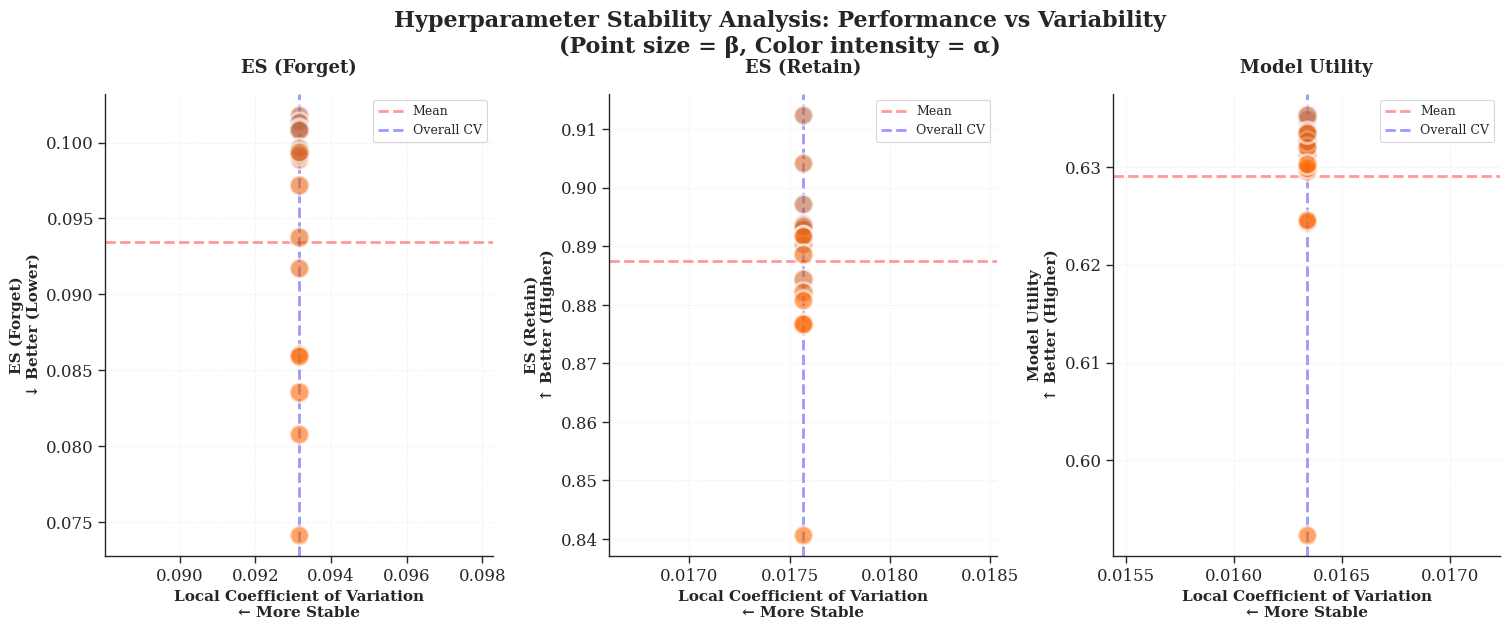


理想配置位于:
  • ES (Forget): 左下角 (低CV + 低值)
  • ES (Retain) 和 Model Utility: 左上角 (低CV + 高值)


In [46]:
# 可视化 1: 性能-稳定性权衡散点图（现代论文风格）
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

for idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(gs[0, idx])
    
    # 计算统计量
    values = df[metric].dropna()
    if len(values) > 1:
        mean_val = values.mean()
        std_val = values.std()
        cv_val = std_val / abs(mean_val) if mean_val != 0 else 0
        
        # 为每个 alpha-beta 组合创建散点
        for _, row in df.iterrows():
            alpha_val = row['alpha']
            beta_val = row['beta']
            metric_val = row[metric]
            
            # 计算该点的局部变异性（使用相邻点）
            nearby = df[(df['alpha'] >= alpha_val - 0.5) & (df['alpha'] <= alpha_val + 0.5) &
                       (df['beta'] >= beta_val - 0.5) & (df['beta'] <= beta_val + 0.5)]
            
            local_cv = nearby[metric].std() / abs(nearby[metric].mean()) if nearby[metric].mean() != 0 else 0
            
            # 使用 alpha-beta 组合为颜色编码
            color_intensity = alpha_val / df['alpha'].max()
            
            ax.scatter(local_cv, metric_val, s=150 + beta_val * 50, 
                      alpha=0.6, c=[[color_intensity, 0.4, 1-color_intensity]],
                      edgecolors='white', linewidth=2, zorder=3)
        
        # 添加全局均值线
        ax.axhline(mean_val, color='red', linestyle='--', alpha=0.4, linewidth=2, label='Mean')
        ax.axvline(cv_val, color='blue', linestyle='--', alpha=0.4, linewidth=2, label='Overall CV')
    
    # 样式设置
    ax.set_xlabel('Local Coefficient of Variation\n← More Stable', 
                 fontsize=11, fontweight='bold')
    
    if metric == 'extraction_strength':
        y_label = f'{key_metric_labels[metric]}\n↓ Better (Lower)'
    else:
        y_label = f'{key_metric_labels[metric]}\n↑ Better (Higher)'
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    
    ax.set_title(key_metric_labels[metric], fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='best', fontsize=9)

fig.suptitle('Hyperparameter Stability Analysis: Performance vs Variability\n(Point size = β, Color intensity = α)',
            fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\n理想配置位于:")
if 'extraction_strength' in df.columns:
    print("  • ES (Forget): 左下角 (低CV + 低值)")
print("  • ES (Retain) 和 Model Utility: 左上角 (低CV + 高值)")
print("="*100)

/tmp/ipykernel_2173/1604654447.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


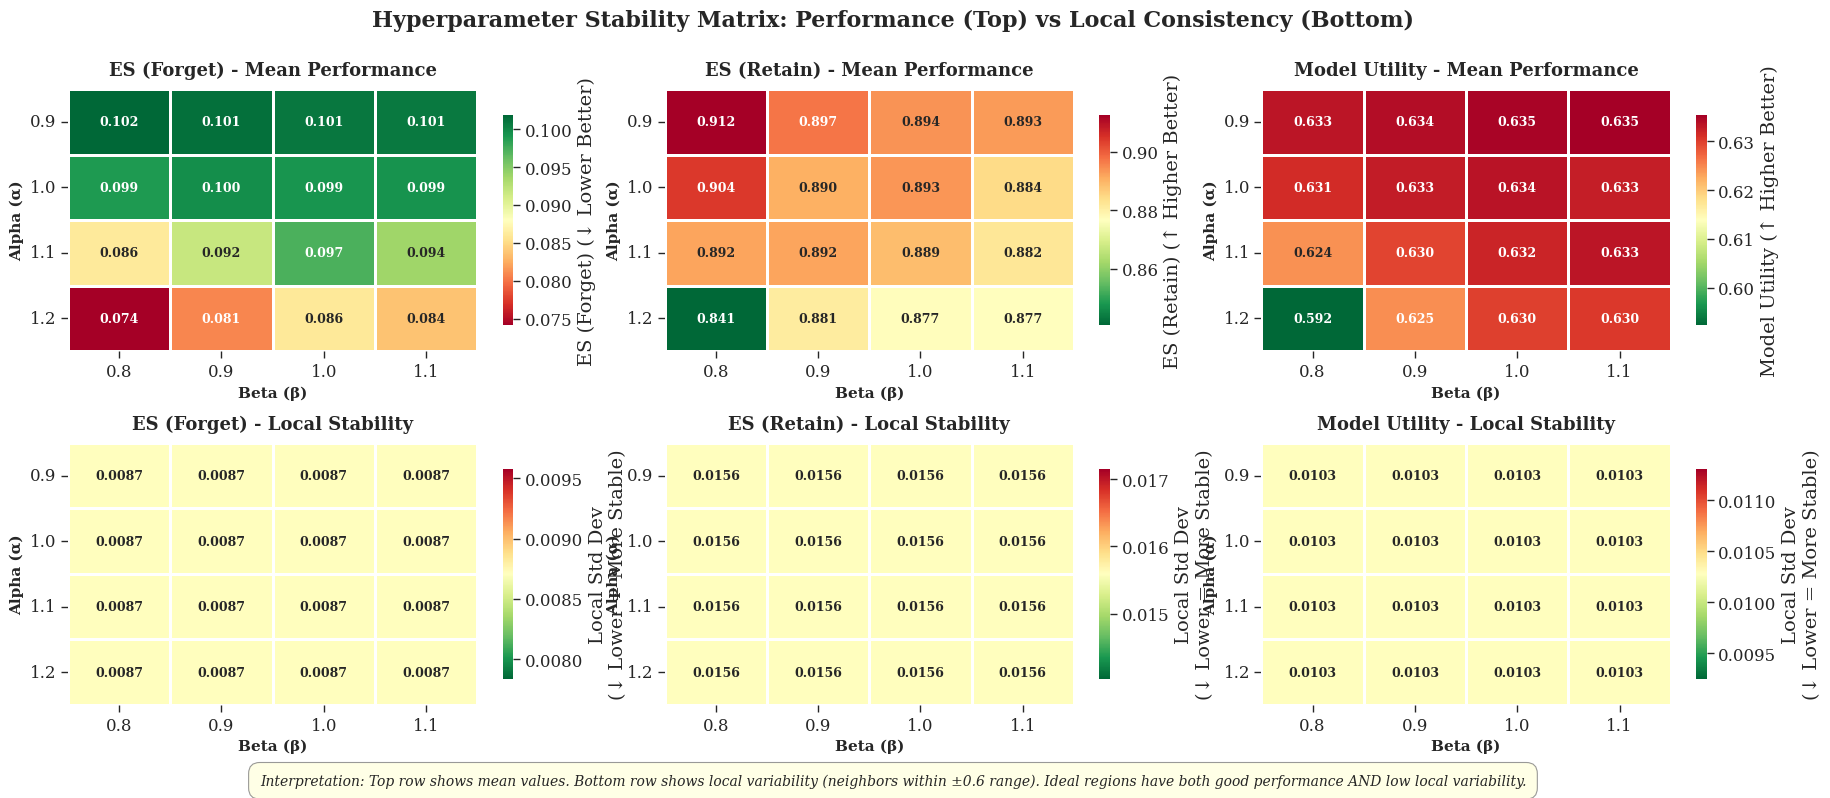


Stability Statistics for Key Metrics

ES (Forget):
  Range: [0.0742, 0.1018]
  Mean ± Std: 0.0935 ± 0.0087
  Coefficient of Variation: 0.0932
  Stability Assessment: 稳定 ★★★★☆

ES (Retain):
  Range: [0.8407, 0.9124]
  Mean ± Std: 0.8874 ± 0.0156
  Coefficient of Variation: 0.0176
  Stability Assessment: 非常稳定 ★★★★★

Model Utility:
  Range: [0.5924, 0.6353]
  Mean ± Std: 0.6290 ± 0.0103
  Coefficient of Variation: 0.0163
  Stability Assessment: 非常稳定 ★★★★★


In [47]:
# 可视化 2: 双层稳定性热力图（性能 + 稳定性）
fig = plt.figure(figsize=(22, 8))
gs = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.4, height_ratios=[1, 1])

# ===== 上层：性能热力图 =====
for idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
    
    pivot = df.pivot(index='alpha', columns='beta', values=metric)
    
    # 根据优化方向选择色图
    if metric == 'extraction_strength':
        cmap = 'RdYlGn'  # 红=高/差，绿=低/好
        label_suffix = '(↓ Lower Better)'
    else:
        cmap = 'RdYlGn_r'  # 绿=高/好，红=低/差
        label_suffix = '(↑ Higher Better)'
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
               cbar_kws={'label': f'{key_metric_labels[metric]} {label_suffix}', 'shrink': 0.8},
               linewidths=1, linecolor='white',
               annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    
    ax.set_title(f'{key_metric_labels[metric]} - Mean Performance', 
                fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Beta (β)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Alpha (α)', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ===== 下层：稳定性热力图（显示标准差或变异范围）=====
for idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(gs[1, idx*2:idx*2+2])
    
    # 由于每个 alpha-beta 组合只有一个数据点，我们计算相邻点的标准差作为局部稳定性指标
    stability_grid = []
    alphas = sorted(df['alpha'].unique())
    betas = sorted(df['beta'].unique())
    
    for alpha_val in alphas:
        stability_row = []
        for beta_val in betas:
            # 获取相邻区域的数据
            neighbors = df[
                (df['alpha'].between(alpha_val - 0.6, alpha_val + 0.6)) &
                (df['beta'].between(beta_val - 0.6, beta_val + 0.6))
            ][metric]
            
            if len(neighbors) > 1:
                local_std = neighbors.std()
            else:
                local_std = 0
            
            stability_row.append(local_std)
        stability_grid.append(stability_row)
    
    stability_df = pd.DataFrame(stability_grid, index=alphas, columns=betas)
    
    # 绘制稳定性热力图（较低的标准差=更稳定=更好=绿色）
    sns.heatmap(stability_df, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax,
               cbar_kws={'label': 'Local Std Dev\n(↓ Lower = More Stable)', 'shrink': 0.8},
               linewidths=1, linecolor='white',
               annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    
    ax.set_title(f'{key_metric_labels[metric]} - Local Stability', 
                fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Beta (β)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Alpha (α)', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# 添加标题
fig.suptitle('Hyperparameter Stability Matrix: Performance (Top) vs Local Consistency (Bottom)',
            fontsize=16, fontweight='bold', y=0.98)

# 添加说明
fig.text(0.5, 0.01,
        'Interpretation: Top row shows mean values. Bottom row shows local variability (neighbors within ±0.6 range). '
        'Ideal regions have both good performance AND low local variability.',
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', 
                 edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

# 打印统计摘要
print(f"\n{'='*100}")
print("Stability Statistics for Key Metrics")
print('='*100)

for metric in key_metrics:
    values = df[metric].dropna()
    if len(values) > 1:
        cv = values.std() / abs(values.mean()) if values.mean() != 0 else 0
        print(f"\n{key_metric_labels[metric]}:")
        print(f"  Range: [{values.min():.4f}, {values.max():.4f}]")
        print(f"  Mean ± Std: {values.mean():.4f} ± {values.std():.4f}")
        print(f"  Coefficient of Variation: {cv:.4f}")
        
        if cv < 0.05:
            stability = "非常稳定 ★★★★★"
        elif cv < 0.10:
            stability = "稳定 ★★★★☆"
        elif cv < 0.20:
            stability = "中等稳定 ★★★☆☆"
        else:
            stability = "不稳定 ★★☆☆☆"
        print(f"  Stability Assessment: {stability}")

print("="*100)

/tmp/ipykernel_2173/3054219152.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


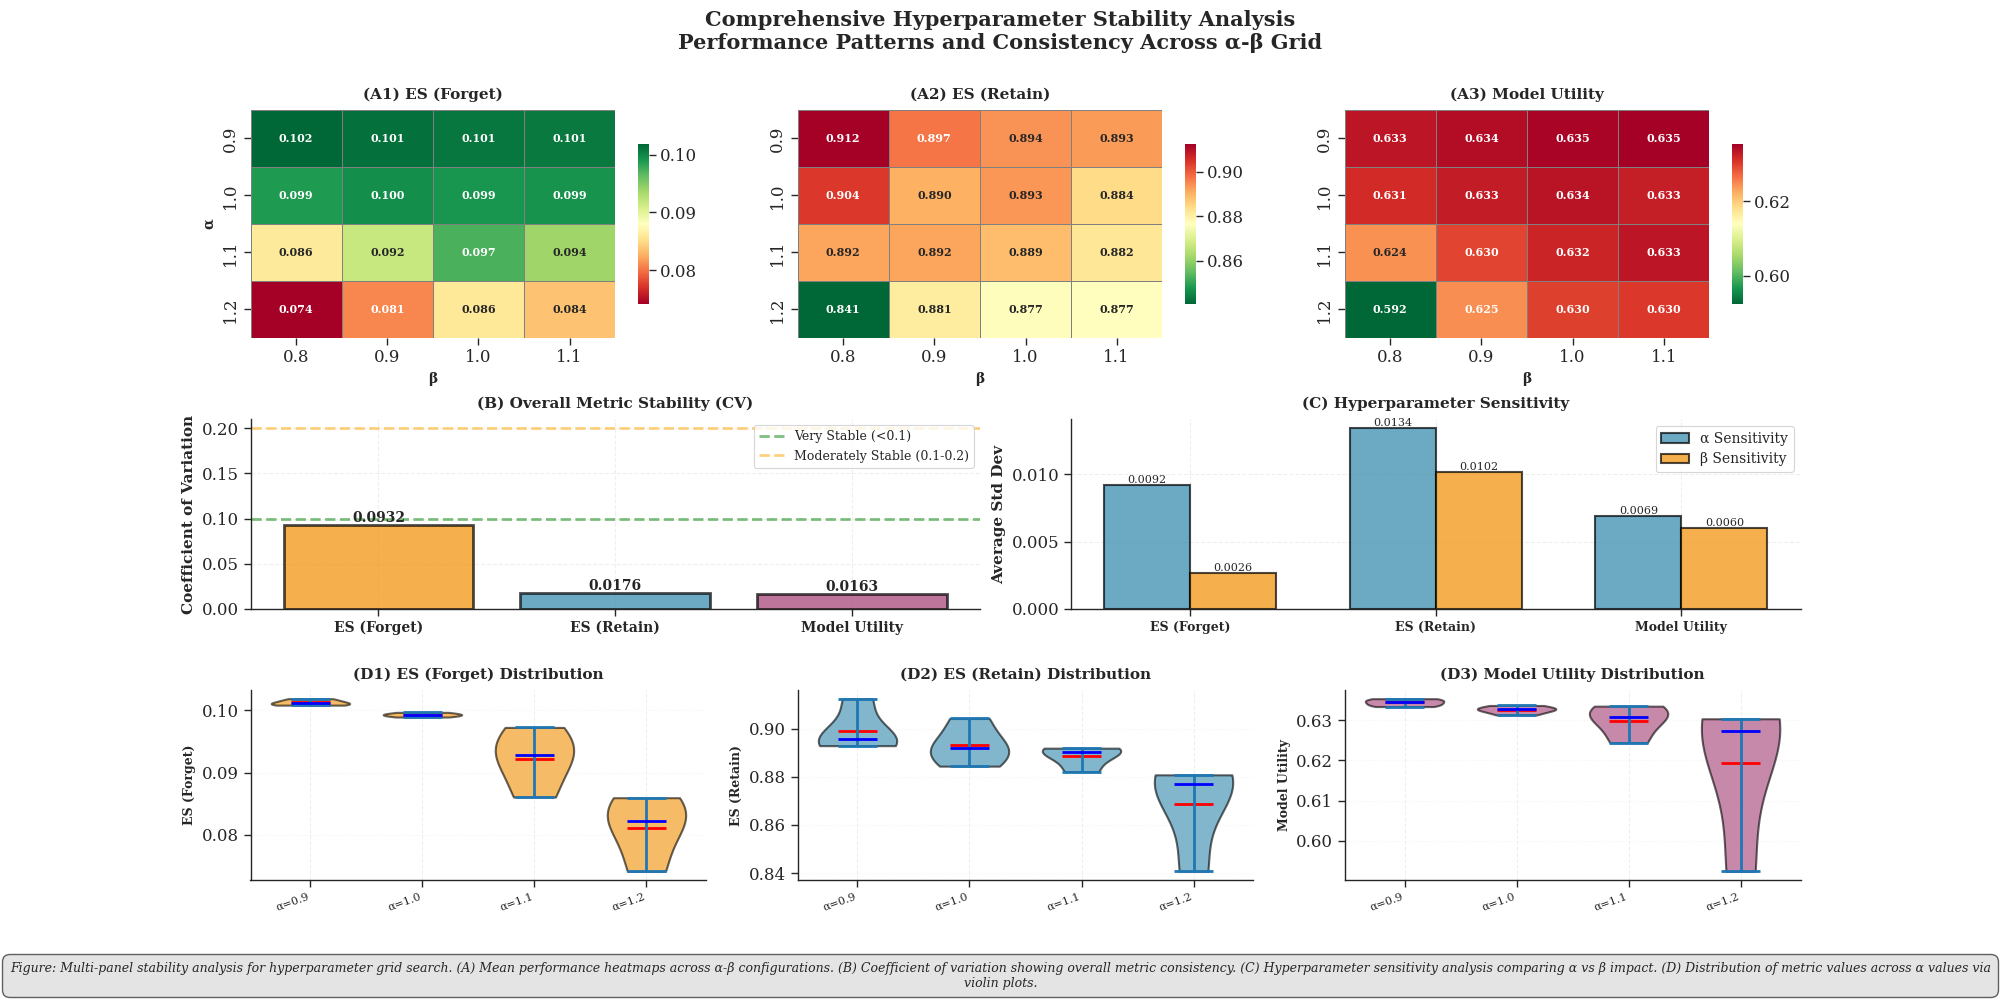


Publication-Ready Stability Dashboard Created
Total Configurations Analyzed: 16
α range: 0.9 - 1.2
β range: 0.8 - 1.1
Metrics Evaluated: ES (Forget), ES (Retain), Model Utility


In [48]:
# 可视化 3: 综合稳定性仪表板（出版级质量，适合会议论文）
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 6, hspace=0.4, wspace=0.5, height_ratios=[1.2, 1, 1])

# ===== Panel A: 性能热力图（3个指标并排）=====
for idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
    
    pivot = df.pivot(index='alpha', columns='beta', values=metric)
    
    if metric == 'extraction_strength':
        cmap = 'RdYlGn'
        vmin, vmax = pivot.min().min(), pivot.max().max()
    else:
        cmap = 'RdYlGn_r'
        vmin, vmax = pivot.min().min(), pivot.max().max()
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
               linewidths=0.5, linecolor='gray', vmin=vmin, vmax=vmax,
               cbar_kws={'shrink': 0.7, 'aspect': 15},
               annot_kws={'fontsize': 8, 'weight': 'bold'})
    
    ax.set_title(f'(A{idx+1}) {key_metric_labels[metric]}', 
                fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('β', fontsize=10, fontweight='bold')
    ax.set_ylabel('α' if idx == 0 else '', fontsize=10, fontweight='bold')
    
    if idx > 0:
        ax.set_ylabel('')

# ===== Panel B: 变异系数 (CV) 条形图 =====
ax_cv = fig.add_subplot(gs[1, :3])

cv_data = []
for metric in key_metrics:
    values = df[metric].dropna()
    if len(values) > 1 and values.mean() != 0:
        cv = values.std() / abs(values.mean())
        cv_data.append({'Metric': key_metric_labels[metric], 'CV': cv})

if cv_data:
    cv_df = pd.DataFrame(cv_data)
    colors_cv = ['#F18F01', '#2E86AB', '#A23B72']
    
    bars = ax_cv.bar(range(len(cv_df)), cv_df['CV'], color=colors_cv, 
                     alpha=0.7, edgecolor='black', linewidth=2)
    
    # 添加数值标签
    for bar, val in zip(bars, cv_df['CV']):
        height = bar.get_height()
        ax_cv.text(bar.get_x() + bar.get_width()/2., height,
                  f'{val:.4f}', ha='center', va='bottom', 
                  fontsize=10, fontweight='bold')
    
    ax_cv.set_xticks(range(len(cv_df)))
    ax_cv.set_xticklabels(cv_df['Metric'], fontsize=10, fontweight='bold')
    ax_cv.set_ylabel('Coefficient of Variation', fontsize=11, fontweight='bold')
    ax_cv.set_title('(B) Overall Metric Stability (CV)', fontsize=11, fontweight='bold', pad=8)
    
    # 添加稳定性阈值线
    ax_cv.axhline(y=0.1, color='green', linestyle='--', alpha=0.5, linewidth=2, 
                 label='Very Stable (<0.1)')
    ax_cv.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, linewidth=2,
                 label='Moderately Stable (0.1-0.2)')
    ax_cv.legend(loc='upper right', fontsize=9)
    ax_cv.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax_cv.spines['top'].set_visible(False)
    ax_cv.spines['right'].set_visible(False)

# ===== Panel C: Alpha-Beta 敏感性分析 =====
ax_sensitivity = fig.add_subplot(gs[1, 3:])

# 计算每个 alpha 和 beta 下的平均性能变化
alpha_sensitivity = {}
beta_sensitivity = {}

for metric in key_metrics:
    # Alpha 敏感性：对每个 beta，计算 alpha 变化导致的标准差
    alpha_sens = []
    for beta_val in df['beta'].unique():
        subset = df[df['beta'] == beta_val][metric]
        if len(subset) > 1:
            alpha_sens.append(subset.std())
    alpha_sensitivity[metric] = np.mean(alpha_sens) if alpha_sens else 0
    
    # Beta 敏感性：对每个 alpha，计算 beta 变化导致的标准差
    beta_sens = []
    for alpha_val in df['alpha'].unique():
        subset = df[df['alpha'] == alpha_val][metric]
        if len(subset) > 1:
            beta_sens.append(subset.std())
    beta_sensitivity[metric] = np.mean(beta_sens) if beta_sens else 0

# 绘制分组条形图
x_pos = np.arange(len(key_metrics))
width = 0.35

bars1 = ax_sensitivity.bar(x_pos - width/2, 
                           [alpha_sensitivity[m] for m in key_metrics],
                           width, label='α Sensitivity', color='#2E86AB', 
                           alpha=0.7, edgecolor='black', linewidth=1.5)

bars2 = ax_sensitivity.bar(x_pos + width/2, 
                           [beta_sensitivity[m] for m in key_metrics],
                           width, label='β Sensitivity', color='#F18F01', 
                           alpha=0.7, edgecolor='black', linewidth=1.5)

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax_sensitivity.text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.4f}', ha='center', va='bottom', fontsize=8)

ax_sensitivity.set_xticks(x_pos)
ax_sensitivity.set_xticklabels([key_metric_labels[m] for m in key_metrics], 
                               fontsize=9, fontweight='bold')
ax_sensitivity.set_ylabel('Average Std Dev', fontsize=11, fontweight='bold')
ax_sensitivity.set_title('(C) Hyperparameter Sensitivity', fontsize=11, fontweight='bold', pad=8)
ax_sensitivity.legend(loc='best', fontsize=10)
ax_sensitivity.grid(True, alpha=0.3, axis='y', linestyle='--')
ax_sensitivity.spines['top'].set_visible(False)
ax_sensitivity.spines['right'].set_visible(False)

# ===== Panel D: 分布小提琴图 =====
colors_violin = ['#F18F01', '#2E86AB', '#A23B72']

for idx, metric in enumerate(key_metrics):
    ax_violin = fig.add_subplot(gs[2, idx*2:idx*2+2])
    
    # 按 alpha 分组绘制小提琴图
    plot_data = []
    plot_labels = []
    
    for alpha_val in sorted(df['alpha'].unique()):
        alpha_data = df[df['alpha'] == alpha_val][metric].dropna()
        if len(alpha_data) > 0:
            plot_data.append(alpha_data)
            plot_labels.append(f'α={alpha_val:.1f}')
    
    if plot_data:
        parts = ax_violin.violinplot(plot_data, positions=range(len(plot_data)),
                                    widths=0.7, showmeans=True, showmedians=True)
        
        # 设置颜色
        for pc in parts['bodies']:
            pc.set_facecolor(colors_violin[idx])
            pc.set_alpha(0.6)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        parts['cmeans'].set_edgecolor('red')
        parts['cmeans'].set_linewidth(2)
        parts['cmedians'].set_edgecolor('blue')
        parts['cmedians'].set_linewidth(2)
        
        ax_violin.set_xticks(range(len(plot_labels)))
        ax_violin.set_xticklabels(plot_labels, rotation=20, ha='right', fontsize=8)
        ax_violin.set_ylabel(key_metric_labels[metric], fontsize=9, fontweight='bold')
        ax_violin.set_title(f'(D{idx+1}) {key_metric_labels[metric]} Distribution', 
                          fontsize=11, fontweight='bold', pad=8)
        ax_violin.grid(True, alpha=0.2, axis='y', linestyle=':')
        ax_violin.spines['top'].set_visible(False)
        ax_violin.spines['right'].set_visible(False)

# 添加总标题
fig.suptitle('Comprehensive Hyperparameter Stability Analysis\n'
            'Performance Patterns and Consistency Across α-β Grid',
            fontsize=15, fontweight='bold', y=0.98)

# 添加图注
caption_text = (
    "Figure: Multi-panel stability analysis for hyperparameter grid search. "
    "(A) Mean performance heatmaps across α-β configurations. "
    "(B) Coefficient of variation showing overall metric consistency. "
    "(C) Hyperparameter sensitivity analysis comparing α vs β impact. "
    "(D) Distribution of metric values across α values via violin plots."
)

fig.text(0.5, 0.005, caption_text,
        ha='center', fontsize=9, style='italic', wrap=True,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgray', 
                 edgecolor='black', alpha=0.6, linewidth=1))

plt.tight_layout()

# 可选：保存高分辨率图片用于论文发表
# output_fig = base_dir / 'publication_stability_analysis.pdf'
# plt.savefig(output_fig, dpi=300, bbox_inches='tight', format='pdf')
# print(f"\nHigh-resolution figure saved: {output_fig}")

plt.show()

print(f"\n{'='*100}")
print("Publication-Ready Stability Dashboard Created")
print('='*100)
print(f"Total Configurations Analyzed: {len(df)}")
print(f"α range: {df['alpha'].min():.1f} - {df['alpha'].max():.1f}")
print(f"β range: {df['beta'].min():.1f} - {df['beta'].max():.1f}")
print(f"Metrics Evaluated: {', '.join([key_metric_labels[m] for m in key_metrics])}")
print("="*100)

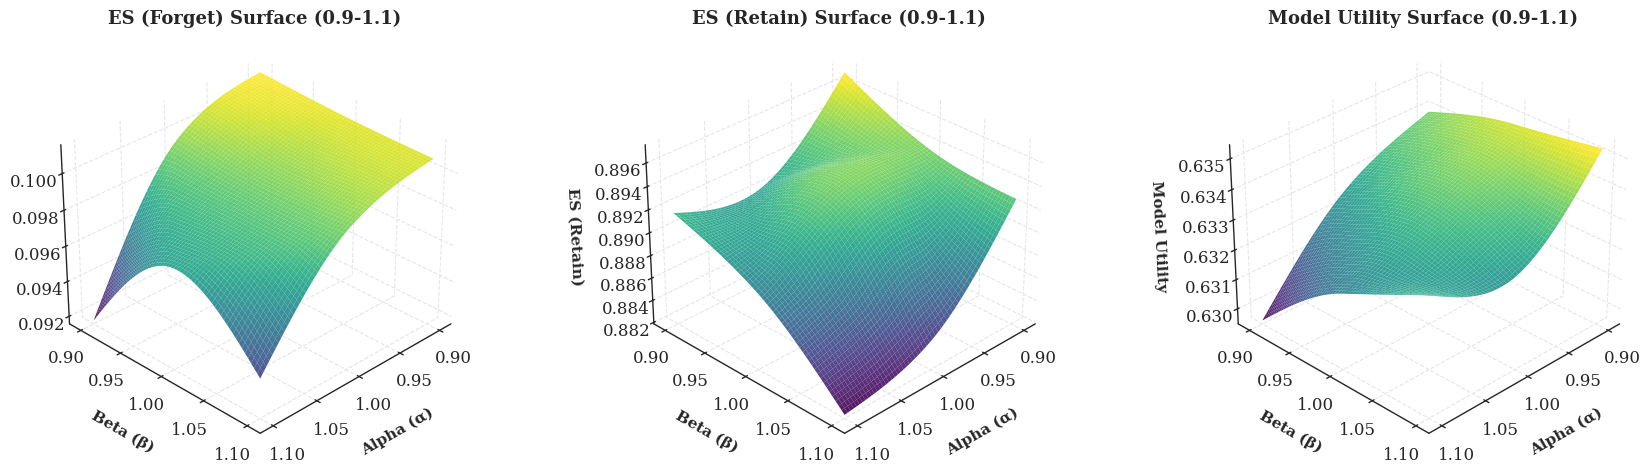


0.9-1.1 范围内的最优配置推荐

ES (Forget):
  Top 5 配置 (Focus Range):
    1. α=1.10, β=0.90 | Value=0.0918
    2. α=1.10, β=1.10 | Value=0.0938
    3. α=1.10, β=1.00 | Value=0.0972
    4. α=1.00, β=1.00 | Value=0.0992
    5. α=1.00, β=1.10 | Value=0.0994

ES (Retain):
  Top 5 配置 (Focus Range):
    1. α=0.90, β=0.90 | Value=0.8972
    2. α=0.90, β=1.00 | Value=0.8939
    3. α=1.00, β=1.00 | Value=0.8935
    4. α=0.90, β=1.10 | Value=0.8929
    5. α=1.10, β=0.90 | Value=0.8917

Model Utility:
  Top 5 配置 (Focus Range):
    1. α=0.90, β=1.10 | Value=0.6353
    2. α=0.90, β=1.00 | Value=0.6348
    3. α=0.90, β=0.90 | Value=0.6340
    4. α=1.00, β=1.00 | Value=0.6336
    5. α=1.10, β=1.10 | Value=0.6335


In [57]:
# 可视化 4: 稳定性最优配置识别（3D 视角） - 纯曲面版 (0.9-1.1 范围)
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

fig = plt.figure(figsize=(18, 5)) # 调整宽长比，使其在论文中占通栏

# 过滤数据范围：只保留 0.9 - 1.1
focus_mask = (df['alpha'] >= 0.9) & (df['alpha'] <= 1.1) & \
             (df['beta'] >= 0.9) & (df['beta'] <= 1.1)
df_focus = df[focus_mask].copy()

if len(df_focus) == 0:
    print("警告：在 0.9-1.1 范围内没有找到数据点！将使用全部数据。")
    df_focus = df.copy()

for idx, metric in enumerate(key_metrics):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    
    # 获取聚焦区域的数据
    alphas = df_focus['alpha'].values
    betas = df_focus['beta'].values
    values = df_focus[metric].values
    
    # 创建更密集的网格用于拟合平滑曲面
    grid_res = 60
    ti_alpha = np.linspace(alphas.min(), alphas.max(), grid_res)
    ti_beta = np.linspace(betas.min(), betas.max(), grid_res)
    TI_alpha, TI_beta = np.meshgrid(ti_alpha, ti_beta)
    
    try:
        # 执行插值
        ZI = griddata((alphas, betas), values, (TI_alpha, TI_beta), method='cubic')
    except Exception:
        # Fallback
        ZI = griddata((alphas, betas), values, (TI_alpha, TI_beta), method='linear')

    # 绘制拟合曲面
    # alpha=0.9 (略微不透明一点，因为没有数据点了，曲面本身就是主角)
    surf = ax.plot_surface(TI_alpha, TI_beta, ZI, cmap='viridis', 
                          edgecolor='none', alpha=0.9, antialiased=True,
                          rstride=1, cstride=1)
    
    # 移除原始数据点的绘制 (ax.scatter)
    
    # 设置标签
    ax.set_xlabel('Alpha (α)', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel('Beta (β)', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_zlabel(key_metric_labels[metric], fontsize=11, fontweight='bold', labelpad=10)
    ax.set_title(f'{key_metric_labels[metric]} Surface (0.9-1.1)', 
                fontsize=13, fontweight='bold', pad=0)
    
    # 优化视角
    ax.view_init(elev=30, azim=45)
    
    # 净化背景
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    
    # 淡化网格线
    ax.xaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)
    ax.yaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)
    ax.zaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig("parameter_stability.pdf", bbox_inches='tight')
plt.show()

# 输出该范围内的 Top 配置
print(f"\n{'='*100}")
print("0.9-1.1 范围内的最优配置推荐")
print('='*100)

for metric in key_metrics:
    print(f"\n{key_metric_labels[metric]}:")
    
    if metric == 'extraction_strength':
        candidates = df_focus.nsmallest(5, metric)
    else:
        candidates = df_focus.nlargest(5, metric)
    
    print(f"  Top 5 配置 (Focus Range):")
    for i, (_, row) in enumerate(candidates.iterrows(), 1):
        print(f"    {i}. α={row['alpha']:.2f}, β={row['beta']:.2f} | Value={row[metric]:.4f}")

print("="*100)

<Figure size 1000x600 with 0 Axes>

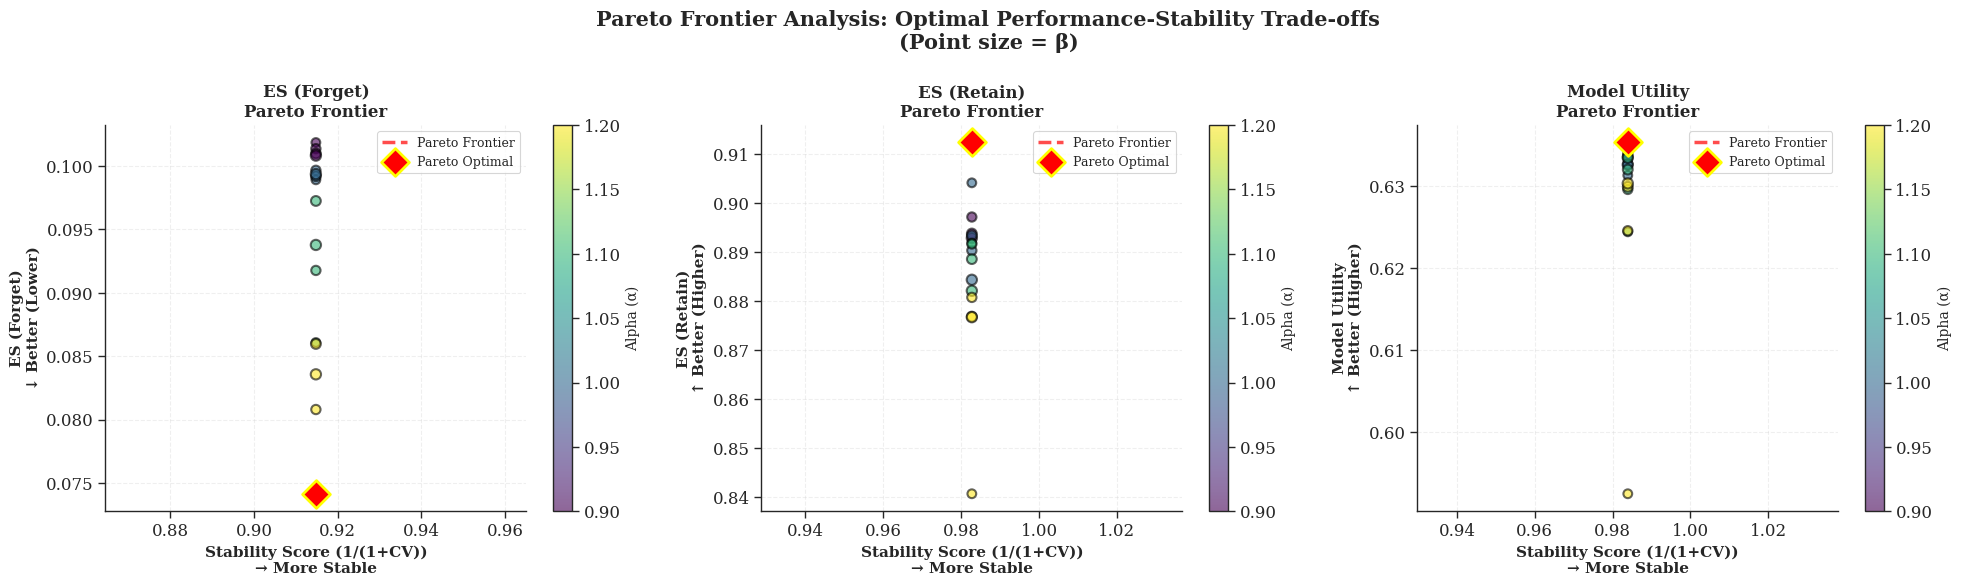


Pareto 最优配置 (性能与稳定性的最佳权衡)

ES (Forget):
  找到 1 个 Pareto 最优配置:
    1. α=1.2, β=0.8 | Performance=0.0742, Stability Score=0.9148

ES (Retain):
  找到 1 个 Pareto 最优配置:
    1. α=0.9, β=0.8 | Performance=0.9124, Stability Score=0.9827

Model Utility:
  找到 1 个 Pareto 最优配置:
    1. α=0.9, β=1.1 | Performance=0.6353, Stability Score=0.9839

解释: Pareto 最优配置表示在性能和稳定性之间没有其他配置能够在两个维度上同时超越它们。


In [50]:
# 可视化 5: Pareto 前沿分析（性能 vs 稳定性权衡）
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, metric in enumerate(key_metrics):
    ax = axes[idx]
    
    # 计算每个配置的性能和局部稳定性
    performance = []
    stability_scores = []
    alphas = []
    betas = []
    
    for _, row in df.iterrows():
        alpha_val = row['alpha']
        beta_val = row['beta']
        metric_val = row[metric]
        
        # 计算局部稳定性
        neighbors = df[
            (df['alpha'].between(alpha_val - 0.6, alpha_val + 0.6)) &
            (df['beta'].between(beta_val - 0.6, beta_val + 0.6))
        ][metric]
        
        local_cv = neighbors.std() / abs(neighbors.mean()) if len(neighbors) > 1 and neighbors.mean() != 0 else 0
        stability_score = 1 / (1 + local_cv)  # 转换为稳定性得分（越高越好）
        
        performance.append(metric_val)
        stability_scores.append(stability_score)
        alphas.append(alpha_val)
        betas.append(beta_val)
    
    # 绘制散点图
    scatter = ax.scatter(stability_scores, performance, 
                        c=alphas, s=[b*50 for b in betas],
                        cmap='viridis', alpha=0.6, 
                        edgecolors='black', linewidth=1.5)
    
    # 识别 Pareto 前沿（对于不同指标有不同定义）
    pareto_indices = []
    for i in range(len(performance)):
        is_pareto = True
        for j in range(len(performance)):
            if i != j:
                if metric == 'extraction_strength':
                    # ES: 越低越好，稳定性越高越好
                    if (performance[j] <= performance[i] and stability_scores[j] >= stability_scores[i] and
                        (performance[j] < performance[i] or stability_scores[j] > stability_scores[i])):
                        is_pareto = False
                        break
                else:
                    # 其他指标: 越高越好，稳定性越高越好
                    if (performance[j] >= performance[i] and stability_scores[j] >= stability_scores[i] and
                        (performance[j] > performance[i] or stability_scores[j] > stability_scores[i])):
                        is_pareto = False
                        break
        
        if is_pareto:
            pareto_indices.append(i)
    
    # 绘制 Pareto 前沿
    if pareto_indices:
        pareto_stability = [stability_scores[i] for i in pareto_indices]
        pareto_performance = [performance[i] for i in pareto_indices]
        
        # 排序以便绘制曲线
        sorted_pairs = sorted(zip(pareto_stability, pareto_performance))
        pareto_stability_sorted = [p[0] for p in sorted_pairs]
        pareto_performance_sorted = [p[1] for p in sorted_pairs]
        
        ax.plot(pareto_stability_sorted, pareto_performance_sorted, 
               'r--', linewidth=2.5, alpha=0.7, label='Pareto Frontier', zorder=5)
        
        # 高亮 Pareto 最优点
        ax.scatter(pareto_stability, pareto_performance, 
                  c='red', s=200, marker='D', 
                  edgecolors='yellow', linewidth=2, 
                  label='Pareto Optimal', zorder=10)
    
    # 添加颜色条
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Alpha (α)', fontsize=10)
    
    # 设置标签
    ax.set_xlabel('Stability Score (1/(1+CV))\n→ More Stable', 
                 fontsize=11, fontweight='bold')
    
    if metric == 'extraction_strength':
        y_label = f'{key_metric_labels[metric]}\n↓ Better (Lower)'
    else:
        y_label = f'{key_metric_labels[metric]}\n↑ Better (Higher)'
    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    
    ax.set_title(f'{key_metric_labels[metric]}\nPareto Frontier', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Pareto Frontier Analysis: Optimal Performance-Stability Trade-offs\n(Point size = β)',
            fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# 输出 Pareto 最优配置
print(f"\n{'='*100}")
print("Pareto 最优配置 (性能与稳定性的最佳权衡)")
print('='*100)

for idx, metric in enumerate(key_metrics):
    print(f"\n{key_metric_labels[metric]}:")
    
    # 重新计算 Pareto 前沿
    performance = []
    stability_scores = []
    configs = []
    
    for _, row in df.iterrows():
        neighbors = df[
            (df['alpha'].between(row['alpha'] - 0.6, row['alpha'] + 0.6)) &
            (df['beta'].between(row['beta'] - 0.6, row['beta'] + 0.6))
        ][metric]
        
        local_cv = neighbors.std() / abs(neighbors.mean()) if len(neighbors) > 1 and neighbors.mean() != 0 else 0
        stability_score = 1 / (1 + local_cv)
        
        performance.append(row[metric])
        stability_scores.append(stability_score)
        configs.append((row['alpha'], row['beta'], row[metric], stability_score))
    
    # 找出 Pareto 最优
    pareto_configs = []
    for i, config in enumerate(configs):
        is_pareto = True
        for j in range(len(configs)):
            if i != j:
                if metric == 'extraction_strength':
                    if (performance[j] <= performance[i] and stability_scores[j] >= stability_scores[i] and
                        (performance[j] < performance[i] or stability_scores[j] > stability_scores[i])):
                        is_pareto = False
                        break
                else:
                    if (performance[j] >= performance[i] and stability_scores[j] >= stability_scores[i] and
                        (performance[j] > performance[i] or stability_scores[j] > stability_scores[i])):
                        is_pareto = False
                        break
        
        if is_pareto:
            pareto_configs.append(config)
    
    # 按性能排序
    if metric == 'extraction_strength':
        pareto_configs.sort(key=lambda x: x[2])  # 升序
    else:
        pareto_configs.sort(key=lambda x: x[2], reverse=True)  # 降序
    
    print(f"  找到 {len(pareto_configs)} 个 Pareto 最优配置:")
    for i, (alpha, beta, perf, stab) in enumerate(pareto_configs[:5], 1):  # 只显示前5个
        print(f"    {i}. α={alpha:.1f}, β={beta:.1f} | "
              f"Performance={perf:.4f}, Stability Score={stab:.4f}")

print("\n" + "="*100)
print("解释: Pareto 最优配置表示在性能和稳定性之间没有其他配置能够在两个维度上同时超越它们。")
print("="*100)